In [1]:
import sys
import os
import glob
import pandas as pd
import numpy as np
from datetime import datetime

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import struct


import funciones_aux as fau

import funciones_dsa as fun_dsa
import funciones_dsa_unilateral as fun_dsa_u
import funciones_dsa_bilateral as fun_dsa_b

import funciones_plot_dsa as fun_plot

from scipy.signal import welch
from matplotlib.colors import LinearSegmentedColormap, PowerNorm
from scipy.stats import pearsonr, spearmanr


# 1. Unilateral

In [58]:

ruta_fa_unilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/M-TA6m-03041035/DH03041035/L03041035.f_a"
ruta_spa_unilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/M-TA6m-03041035/DH03041035/L03041035.spa"
ruta_ha_unilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/M-TA6m-03041035/DH03041035/L03041035.h_a"
ruta_ta_unilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/M-TA6m-03041035/DH03041035/L03041035.t_a"

archivo_r2a = r"C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/M-TA6m-03041035/DH03041035/L03041035.r2a"


In [59]:
# este es para el bis vista que no tiene fa
"""
ruta_spa_unilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_antiguo/L03041419/L03041419/L03041419.spa"
ruta_ha_unilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_antiguo/L03041419/L03041419/L03041419.h_a"
ruta_ta_unilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_antiguo/L03041419/L03041419/L03041419.t_a"

archivo_r2a = r"C:/Users/usuario/TFG_BIS_GIS/data/data_bis_antiguo/L03041419/L03041419/L03041419.r2a"
"""

'\nruta_spa_unilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_antiguo/L03041419/L03041419/L03041419.spa"\nruta_ha_unilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_antiguo/L03041419/L03041419/L03041419.h_a"\nruta_ta_unilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_antiguo/L03041419/L03041419/L03041419.t_a"\n\narchivo_r2a = r"C:/Users/usuario/TFG_BIS_GIS/data/data_bis_antiguo/L03041419/L03041419/L03041419.r2a"\n'

## 1. 1.  Archivo Espectral .f_a

In [60]:
tiempo_fa_unilat, dsa_unilat = fau.cargar_fa_directo(ruta_fa_unilat, escalar_db=True)

print("Dimensiones de la matriz:", dsa_unilat.shape)
print("Frecuencias:", dsa_unilat.columns.min(), "a", dsa_unilat.columns.max(), "Hz")

Dimensiones de la matriz: (2119, 60)
Frecuencias: 0.5 a 30.0 Hz


## 1. 2. Archivo variables procesadas .spa

In [61]:
df_spa_raw = fau.procesar_spa(ruta_spa_unilat)
df_spa_unilat = fun_dsa_u.limpiar_spa_unilateral(df_spa_raw)

print("Dimensiones del archivo procesado:", df_spa_unilat.shape)
#display(df_spa_unilat.head())

Dimensiones del archivo procesado: (2119, 12)


In [62]:
# Extraer SpSmooth del .spa y traducirlo a segundos

valor_spsmooth_unilat, suavizado_spsmooth_unilat, dist_spsmooth_unilat = (
    fau.extraer_spsmooth_segundos(
        df_spa_unilat,
        verbose=True
    )
)

SpSmooth codificado más frecuente: 3
Suavizado espectral equivalente: 30 s

Distribución de valores SpSmooth:


SpSmooth
3    2119
Name: count, dtype: int64

### timeline oficial del .spa

In [63]:
timeline_spa_unilat = fun_dsa_b.preparar_timeline_spa(
    df_spa=df_spa_unilat,
    columna_time="Time",
    resolver_duplicados="last",
    verbose=True
)

=== Timeline .spa ===
Inicio .spa: 2026-03-04 10:35:21
Fin .spa: 2026-03-04 11:10:39
N segundos .spa: 2119


### ajustar .f_a a la timeline del .spa

In [64]:
dsa_fa_unilat_spa = fun_dsa_b.ajustar_dsa_a_timeline_spa(
    tiempo_dsa=tiempo_fa_unilat,
    dsa=dsa_unilat,
    timeline_spa=timeline_spa_unilat,
    nombre="f_a unilateral",
    verbose=True
)

f_a unilateral: ya coincide con la timeline del .spa. No se modifica.


### Fusión .f_a y .spa

In [65]:
df_merge_fa = fun_dsa.alinear_spa_con_tiempo(
    timeline_spa_unilat,
    df_spa_unilat,
    resolver_duplicados="last"
)

sef_hor = df_merge_fa["SEF08"]
mf_hor = df_merge_fa["MEDFRQ08"]

In [66]:
print("timeline_spa:", len(timeline_spa_unilat))
print("df_merge_fa:", df_merge_fa.shape)

timeline_spa: 2119
df_merge_fa: (2119, 8)


### Cabecera

In [67]:
num_canales, fs, pendiente, offset = fau.extraer_parametros_eeg(ruta_ha_unilat)
print("Parámetros extraídos con éxito:")
print(f" - Canales: {num_canales}")
print(f" - Frecuencia (Hz): {fs}")
print(f" - Pendiente (m): {pendiente:.8f}")
print(f" - Offset (b): {offset:.4f}")

Parámetros extraídos con éxito:
 - Canales: 2
 - Frecuencia (Hz): 128
 - Pendiente (m): 0.05000000
 - Offset (b): -3234.0000


## 1. 3 Archivo ondas crudas .r2a

In [68]:
df_eeg_unilat = fun_dsa_u.leer_r2a(
    archivo_r2a,
    pendiente,
    offset,
    fs=fs
)

In [69]:
df_eeg_recortado, timeline_spa_unilat, info_alineacion = (
    fun_dsa_b.recortar_raw_segun_ta_y_spa(
        df_raw=df_eeg_unilat,
        ruta_ta=ruta_ta_unilat,
        df_spa=df_spa_unilat,
        columna_time="Time",
        fs=128,
        resolver_duplicados="last",
        verbose=True
    )
)

# Usar el inicio del .spa como inicio de la DSA reconstruida
hora_inicio = timeline_spa_unilat.iloc[0]

print("Raw unilateral original:", df_eeg_unilat.shape)
print("Raw unilateral recortado:", df_eeg_recortado.shape)
print("Timeline SPA:", len(timeline_spa_unilat))

=== Timeline .spa ===
Inicio .spa: 2026-03-04 10:35:21
Fin .spa: 2026-03-04 11:10:39
N segundos .spa: 2119
=== Alineación raw a timeline .spa ===
Inicio raw (.t_a): 2026-03-04 10:35:21
Inicio .spa: 2026-03-04 10:35:21
Fin .spa: 2026-03-04 11:10:39
Desfase spa - raw: 0.0 s
Acción inicio: sin_recorte_inicio
Segundos objetivo .spa: 2119
Muestras objetivo: 271232
Muestras raw originales: 271312
Muestras recortadas inicio: 0
Muestras NaN inicio: 0
Muestras recortadas final: 0
Muestras NaN final: 0
Muestras raw alineado: 271232
Duración raw alineado: 2119.0 s
Raw unilateral original: (271312, 5)
Raw unilateral recortado: (271232, 5)
Timeline SPA: 2119


### 1. 3. 1. Reconstrucción

In [70]:
ventana_seg =2
paso_seg =1

df_dsa_canal1, frecuencias_c1 = fun_dsa.crear_matriz_dsa_fft_welch_desde_eeg(
    df_eeg_recortado,
    "canal_1_uV",
    fs=128,
    ventana_seg=ventana_seg,
    paso_seg=paso_seg,
    fmin=0.5,
    fmax=30.0,
    paso_freq=0.5,
    modo="densidad",
    tiempo_referencia="centro"
)

df_dsa_canal2, _ = fun_dsa.crear_matriz_dsa_fft_welch_desde_eeg(
    df_eeg_recortado,
    "canal_2_uV",
    fs=128,
    ventana_seg=ventana_seg,
    paso_seg=paso_seg,
    fmin=0.5,
    fmax=30.0,
    paso_freq=0.5,
    modo="densidad", 
    tiempo_referencia="centro"
)

In [71]:
# -------------------- Depende del modo que pongamos las uds son uV^2 o uV^2/Hz (uds. potencia)--------------------

# columnas del dF generado después de la conversión por FFT -> las frecuencias
cols_freq = [c for c in df_dsa_canal1.columns if c != "tiempo_s"]

# copia del dF del canal 1 para tener esa estructura
df_dsa_media = df_dsa_canal1.copy()

# media (en float) de las potencias (en uV) de los 2 canales
# en función de las frecuencias 
pot_media = (
    df_dsa_canal1[cols_freq].to_numpy(dtype=float) +
    df_dsa_canal2[cols_freq].to_numpy(dtype=float)
) / 2

In [72]:

# ----------- CONVERSIÓN A DECIBELIOS (ref documentación del BIS) -----------------------------------
ref_potencia = 0.0001


df_dsa_media[cols_freq] = 10 * np.log10(
    (pot_media + 1e-12) / (ref_potencia**2)
)

### 1. 3. 2. Adaptación temporal, máscara y plot de DSA EEG

In [73]:
hora_inicio = timeline_spa_unilat.iloc[0]

# ----------------- Adaptación temporal inicial de la DSA reconstruida ---------------------------

tiempo_eeg_tmp, dsa_eeg_tmp = fun_dsa.adaptar_dsa_reconstruida_para_plot(
    df_dsa=df_dsa_media,
    frecuencias=frecuencias_c1,
    hora_inicio=hora_inicio,
    insertar_fila_inicial_nan=True
)

# ---------------- Ajustar reconstruida a la timeline oficial del .spa ---------------------------

dsa_eeg_unilat_spa = fun_dsa_b.ajustar_dsa_a_timeline_spa(
    tiempo_dsa=tiempo_eeg_tmp,
    dsa=dsa_eeg_tmp,
    timeline_spa=timeline_spa_unilat,
    nombre="DSA EEG reconstruida unilateral",
    verbose=True
)

DSA EEG reconstruida unilateral: ya coincide con la timeline del .spa. No se modifica.


In [74]:
# Desde aquí, el tiempo oficial de la reconstruida también es el del .spa
tiempo_eeg_unilat = timeline_spa_unilat.copy()


# Merge del .spa para la reconstruida
df_merge_eeg = fun_dsa.alinear_spa_con_tiempo(
    tiempo=tiempo_eeg_unilat,
    df_spa=df_spa_unilat,
    resolver_duplicados="last"
)

sef_hor = df_merge_eeg["SEF08"]
mf_hor = df_merge_eeg["MEDFRQ08"]

### Máscaras de calidad bilateral - común

In [75]:
_, mask_comun_unilat = fun_dsa.preparar_dsa_con_mask(
    tiempo=timeline_spa_unilat,
    dsa=dsa_eeg_unilat_spa,
    df_merge=df_merge_eeg,
    umbral_sqi=15,
    umbral_ceros=0.9,
    incluir_filas_nan=True
)

mask_comun = mask_comun_unilat.copy()

# en las reconstrucciones se utilizan como valores mínimos y máximos 
# los percentiles más ajustados para replicar el color

print(f"Filas totales:", len(mask_comun))
print(f"\nFilas enmascaradas:", mask_comun.sum())
print(f"\nFilas válidas:", (~mask_comun).sum())

Filas totales: 2119

Filas enmascaradas: 146

Filas válidas: 1973


#### Añadir posibles huecos del .f_a, si existe archivo espectral

In [76]:
# Filas completamente NaN del .f_a ajustado al .spa (comprobación adicional por si acaso)
mask_fa_nan = dsa_fa_unilat_spa.isna().all(axis=1)

mask_comun = mask_comun | mask_fa_nan


print("NaN f_a:", mask_fa_nan.sum())
print("\nFilas enmascaradas finales:", mask_comun.sum())
print("\nFilas válidas finales:", (~mask_comun).sum())

NaN f_a: 0

Filas enmascaradas finales: 146

Filas válidas finales: 1973


#### Aplicación

In [77]:
# DSA reconstruida directa con máscara común ------------------- EEG --------------------------------------------------

""" 
Copia de la dsa proveniente del eeg para incluirla en el plot
 - .loc[mask_comun.values, :]: selecciona todas las filas donde mask_comun vale True, y todas las columnas de frecuencia.
 - np.nan: como el colormap pinta los NaN en blanco, esas filas aparecerán como bandas blancas.
"""

dsa_eeg_plot = dsa_eeg_unilat_spa.copy()
dsa_eeg_plot.loc[mask_comun.values, :] = np.nan

In [78]:
# DSA original f_a con máscara común ------------------------------- FA ---------------------------------------------------

""" 
Copia de la dsa proveniente del f_a para incluirla en el plot
 - .loc[mask_comun.values, :]: selecciona todas las filas donde mask_comun vale True, y todas las columnas de frecuencia.
 - np.nan: como el colormap pinta los NaN en blanco, esas filas aparecerán como bandas blancas.
"""

dsa_fa_plot = dsa_fa_unilat_spa.copy()
dsa_fa_plot.loc[mask_comun.values, :] = np.nan

#### Comprobación

In [79]:
# ============================================================
# Comprobación de bandas blancas tras aplicar máscara unilateral
# ============================================================

# 1. Detectar filas completamente blancas en cada matriz
mask_blanca_eeg = dsa_eeg_plot.isna().all(axis=1)
mask_blanca_fa = dsa_fa_plot.isna().all(axis=1)


# 2. Comprobar que las bandas blancas coinciden con la máscara aplicada
print("=== COMPROBACIÓN UNILATERAL ===")

print("EEG coincide con mask_comun:")
print((mask_blanca_eeg.values == mask_comun.values).all())

print("FA coincide con mask_comun:")
print((mask_blanca_fa.values == mask_comun.values).all())

print("\nBandas blancas EEG:", mask_blanca_eeg.sum())
print("Bandas blancas FA:", mask_blanca_fa.sum())
print("Filas en mask_comun:", mask_comun.sum())

print("\nDiferencias EEG vs máscara:")
print((mask_blanca_eeg.values != mask_comun.values).sum())

print("Diferencias FA vs máscara:")
print((mask_blanca_fa.values != mask_comun.values).sum())


# 3. Tabla para localizar posibles diferencias
df_check_blancas_unilat = pd.DataFrame({
    "Time": timeline_spa_unilat.reset_index(drop=True),

    "mask_comun": mask_comun.reset_index(drop=True),
    "blanca_eeg": mask_blanca_eeg.reset_index(drop=True),
    "blanca_fa": mask_blanca_fa.reset_index(drop=True),
})

df_check_blancas_unilat["diff_eeg"] = (
    df_check_blancas_unilat["mask_comun"] !=
    df_check_blancas_unilat["blanca_eeg"]
)

df_check_blancas_unilat["diff_fa"] = (
    df_check_blancas_unilat["mask_comun"] !=
    df_check_blancas_unilat["blanca_fa"]
)


# 4. Mostrar solo filas problemáticas, si las hay
df_diferencias_blancas_unilat = df_check_blancas_unilat[
    df_check_blancas_unilat[["diff_eeg", "diff_fa"]].any(axis=1)
]

print("\nNúmero total de filas con alguna diferencia:")
print(len(df_diferencias_blancas_unilat))

display(df_diferencias_blancas_unilat.head(50))

=== COMPROBACIÓN UNILATERAL ===
EEG coincide con mask_comun:
True
FA coincide con mask_comun:
True

Bandas blancas EEG: 146
Bandas blancas FA: 146
Filas en mask_comun: 146

Diferencias EEG vs máscara:
0
Diferencias FA vs máscara:
0

Número total de filas con alguna diferencia:
0


,Time,mask_comun,blanca_eeg,blanca_fa,diff_eeg,diff_fa


### 1. 3. 3. Preparar escala de color de f_a y eeg reconstruida

In [80]:
# DSA reconstruida ------------------------------------------------ EEG -----------------------------------------------

matriz_eeg, vmin_eeg, vmax_eeg, norm_eeg, cmap_eeg = fun_dsa.preparar_escala_color_dsa(
    dsa_eeg_plot,
    gamma=0.4
)

In [81]:
# DSA original ---------------------------------------------------- FA --------------------------------------------------

# las matrices que vienen de la f_a suelen mostrar valores entre el 49 y 94
matriz_fa, vmin_fa, vmax_fa, norm_fa, cmap_fa = fun_dsa.preparar_escala_color_dsa(
    dsa_fa_plot,
    vmin=49,
    vmax=94,
    gamma=1
)

### 1. 3. 4. Visualización r2a

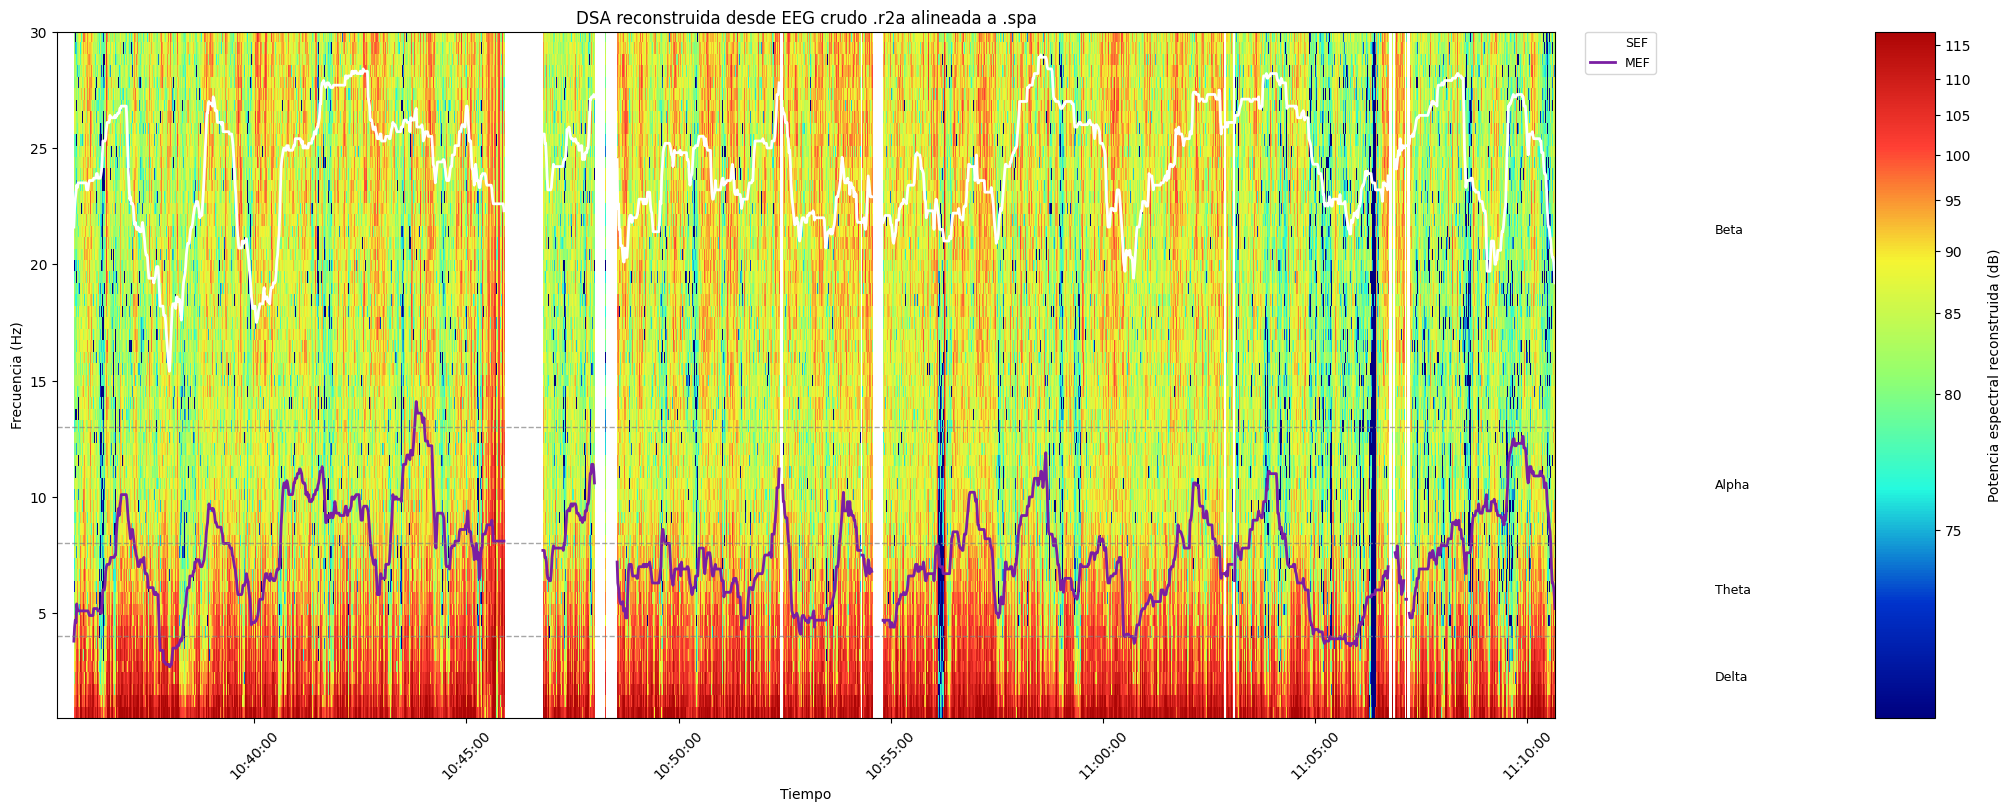

In [82]:
fig_eeg, ax_eeg, ax_band_eeg, cax_eeg = fun_plot.plot_dsa_con_sef_mef(
    tiempo=timeline_spa_unilat,
    frecuencias=dsa_eeg_plot.columns.astype(float),
    matriz=matriz_eeg,
    norm=norm_eeg,
    cmap=cmap_eeg,
    df_merge=df_merge_eeg,
    titulo="DSA reconstruida desde EEG crudo .r2a alineada a .spa",
    etiqueta_colorbar="Potencia espectral reconstruida (dB)",
    mostrar_sef=True,
    mostrar_mef=True,
    mask_total=mask_comun
)

###  Visualización .f_a

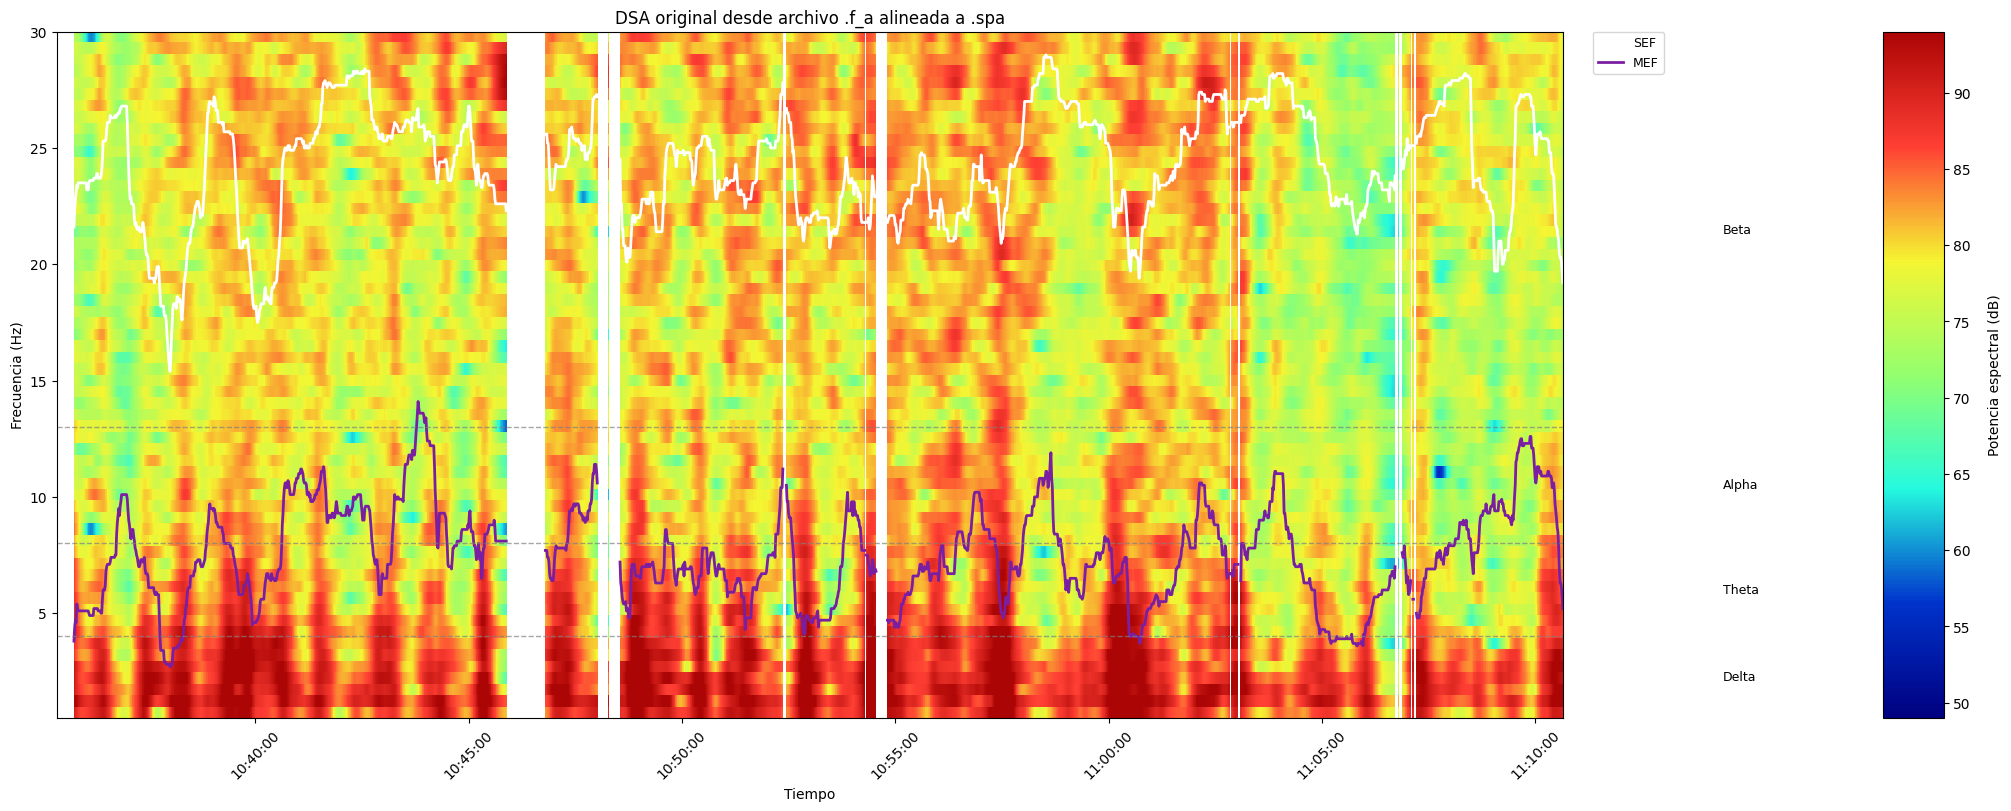

In [83]:
frecuencias_fa = dsa_fa_plot.columns.astype(float)

fig_fa, ax_fa, ax_band_fa, cax_fa = fun_plot.plot_dsa_con_sef_mef(
    tiempo=timeline_spa_unilat,
    frecuencias=frecuencias_fa,
    matriz=matriz_fa,
    norm=norm_fa,
    cmap=cmap_fa,
    df_merge=df_merge_fa,
    titulo="DSA original desde archivo .f_a alineada a .spa",
    etiqueta_colorbar="Potencia espectral (dB)",
    mostrar_sef=True,
    mostrar_mef=True,
    mask_total=mask_comun
)

## 1. 4. Comprobaciones

In [84]:
# ============================================================
# Comprobación de tamaños unilateral
# ============================================================

print("timeline_spa_unilat:", len(timeline_spa_unilat))

print("FA ajustado:", dsa_fa_unilat_spa.shape)
print("EEG ajustado:", dsa_eeg_unilat_spa.shape)

print("merge FA:", df_merge_fa.shape)
print("merge EEG:", df_merge_eeg.shape)

print("plot FA:", dsa_fa_plot.shape)
print("plot EEG:", dsa_eeg_plot.shape)

print("mask_comun:", len(mask_comun))

timeline_spa_unilat: 2119
FA ajustado: (2119, 60)
EEG ajustado: (2119, 60)
merge FA: (2119, 8)
merge EEG: (2119, 8)
plot FA: (2119, 60)
plot EEG: (2119, 60)
mask_comun: 2119


In [85]:
# ============================================================
# Rango de valores - DSA reconstruida
# ============================================================

cols_freq_eeg = [c for c in dsa_eeg_plot.columns]

print("Mínimos y máximos - RECONSTRUCCIÓN")
print(np.nanmin(dsa_eeg_plot[cols_freq_eeg].values))
print(np.nanmax(dsa_eeg_plot[cols_freq_eeg].values))

print("\nPercentiles mínimos y máximos - RECONSTRUCCIÓN")
print(np.nanpercentile(dsa_eeg_plot[cols_freq_eeg].values, 2))
print(np.nanpercentile(dsa_eeg_plot[cols_freq_eeg].values, 99.5))

Mínimos y máximos - RECONSTRUCCIÓN
43.70621522483941
131.80276493404725

Percentiles mínimos y máximos - RECONSTRUCCIÓN
73.28325791047043
117.11260727678965


In [86]:
# ============================================================
# Rango de valores - DSA .f_a
# ============================================================

cols_freq_fa = [c for c in dsa_fa_plot.columns]

print("Mínimos y máximos - FA")
print(np.nanmin(dsa_fa_plot[cols_freq_fa].values))
print(np.nanmax(dsa_fa_plot[cols_freq_fa].values))

print("\nPercentiles mínimos y máximos - FA")
print(np.nanpercentile(dsa_fa_plot[cols_freq_fa].values, 2))
print(np.nanpercentile(dsa_fa_plot[cols_freq_fa].values, 99.5))

Mínimos y máximos - FA
55.61
103.02

Percentiles mínimos y máximos - FA
70.0
96.87


## 1. 5. Métricas y comparación

### 1. 5. 1.  Comparación base

In [87]:
dsa_eeg_comparacion, dsa_fa_comparacion = fun_dsa.preparar_matrices_para_comparacion(
    dsa_eeg_plot,
    dsa_fa_plot
)

dsa_eeg_z = fun_dsa.zscore_global(dsa_eeg_comparacion)
dsa_fa_z = fun_dsa.zscore_global(dsa_fa_comparacion)

metricas_base = fun_dsa.comparar_dsa_global(
    dsa_eeg_z,
    dsa_fa_z
)

metricas_base

{'n_valores_comparados': 118380,
 'MAE': np.float64(0.8490502140250622),
 'RMSE': np.float64(1.0922926784115914),
 'bias_B_menos_A': np.float64(2.557905830980945e-15),
 'Pearson': np.float64(0.403448352344216),
 'Spearman': np.float64(0.321131738478958)}

## 1. 6. Suavizado + shift

In [88]:
dsa_eeg_comp_sin_mask, dsa_fa_comp_sin_mask = fun_dsa.preparar_matrices_para_comparacion(
    dsa_eeg_unilat_spa,
    dsa_fa_unilat_spa
)

In [89]:
ventanas_sp_smooth_probar = [1, 5, 10, 30, 60]

print("Ventanas a probar:", ventanas_sp_smooth_probar)
print("Ventana indicada por SpSmooth:", suavizado_spsmooth_unilat, "s")

ventanas_sp_smooth_unilat = [suavizado_spsmooth_unilat]

Ventanas a probar: [1, 5, 10, 30, 60]
Ventana indicada por SpSmooth: 30 s


In [90]:
df_suav_shift = fun_dsa.probar_suavizado_y_shifts(
    dsa_eeg_comp_sin_mask,
    dsa_fa_comp_sin_mask,
    ventanas_suavizado= ventanas_sp_smooth_probar,
    shifts=range(0, 31)
)

df_suav_shift.sort_values("Pearson", ascending=False).head(7)

,suavizado_s,shift_s,Pearson,Spearman,MAE,RMSE
103,30,10,0.687146,0.691482,0.575243,0.790843
104,30,11,0.686814,0.690483,0.576006,0.791275
102,30,9,0.686745,0.691323,0.575357,0.791341
105,30,12,0.685750,0.688342,0.577704,0.792627
101,30,8,0.685618,0.690015,0.576366,0.792756
106,30,13,0.683974,0.685089,0.580245,0.794874
100,30,7,0.683796,0.687595,0.578313,0.795045


### 1. 6. 1. Tabla resumen final

In [91]:
mejor_pearson = df_suav_shift.sort_values("Pearson", ascending=False).iloc[0]
mejor_spearman = df_suav_shift.sort_values("Spearman", ascending=False).iloc[0]

df_resumen_final = pd.DataFrame([
    {
        "criterio": "Mejor Pearson",
        "suavizado_s": mejor_pearson["suavizado_s"],
        "shift_s": mejor_pearson["shift_s"],
        "Pearson": mejor_pearson["Pearson"],
        "Spearman": mejor_pearson["Spearman"],
        "MAE": mejor_pearson["MAE"],
        "RMSE": mejor_pearson["RMSE"],
    },
    {
        "criterio": "Mejor Spearman",
        "suavizado_s": mejor_spearman["suavizado_s"],
        "shift_s": mejor_spearman["shift_s"],
        "Pearson": mejor_spearman["Pearson"],
        "Spearman": mejor_spearman["Spearman"],
        "MAE": mejor_spearman["MAE"],
        "RMSE": mejor_spearman["RMSE"],
    }
])

df_resumen_final

,criterio,suavizado_s,shift_s,Pearson,Spearman,MAE,RMSE
0,Mejor Pearson,30.0,10.0,0.687146,0.691482,0.575243,0.790843
1,Mejor Spearman,30.0,10.0,0.687146,0.691482,0.575243,0.790843


## 1. 7. Optimizaciones - Suavizado limpio

In [92]:
suavizado_final = suavizado_spsmooth_unilat

dsa_eeg_suav_unilat = dsa_eeg_unilat_spa.copy().rolling(
    window=suavizado_final,
    min_periods=1,
    center=False
).mean()

In [93]:
# máscara común al final
dsa_eeg_suav_plot_unilat = dsa_eeg_suav_unilat.copy()
dsa_eeg_suav_plot_unilat.loc[mask_comun.values, :] = np.nan

matriz_opt_unilat, vmin_opt_unilat, vmax_opt_unilat, norm_opt_unilat, cmap_opt_unilat = fun_dsa.preparar_escala_color_dsa(
    dsa_eeg_suav_plot_unilat,
    gamma=0.25
)

### 1. 7. 1. Comprobación bandas blancas

In [94]:
mask_blanca_suav = dsa_eeg_suav_plot_unilat.isna().all(axis=1)
mask_blanca_eeg = dsa_eeg_plot.isna().all(axis=1)
mask_blanca_fa = dsa_fa_plot.isna().all(axis=1)

print("bandas blancas directa vs suavizada")
print((mask_blanca_eeg == mask_blanca_suav).all())

print("Diferencias:")
print((mask_blanca_eeg != mask_blanca_suav).sum())

bandas blancas directa vs suavizada
True
Diferencias:
0


## 1. 8. Optimizaciones - Suavizado + shift

In [99]:
shift_final = int(mejor_pearson["shift_s"])  # en tu caso 10

# matriz desplazada sin máscara
dsa_eeg_suav_shift_full = pd.DataFrame(
    np.nan,
    index=dsa_eeg_suav_unilat.index,
    columns=dsa_eeg_suav_unilat.columns
)

dsa_eeg_suav_shift_full.iloc[shift_final:, :] = (
    dsa_eeg_suav_unilat.iloc[:-shift_final, :].to_numpy()
)

# matriz desplazada para plot, con máscara
dsa_eeg_suav_shift_plot = dsa_eeg_suav_shift_full.copy()
dsa_eeg_suav_shift_plot.loc[mask_comun.values, :] = np.nan


Tiempo: 2119
f_a: (2119, 60)
shift full: (2119, 60)


In [102]:
matriz_opt_desfase_full, vmin_opt_desfase_full, vmax_opt_desfase_full, norm_opt_desfase_full, cmap_opt_desfase_full = fun_dsa.preparar_escala_color_dsa(
    dsa_eeg_suav_shift_plot,
    gamma=0.25
)

print("Tiempo:", len(timeline_spa_unilat))
print("f_a:", matriz_fa.shape)
print("shift full:", matriz_opt_desfase_full.shape)

Tiempo: 2119
f_a: (2119, 60)
shift full: (2119, 60)


In [101]:
# ============================================================
# Comprobación bandas blancas: suavizada vs suavizada + shift
# ============================================================

mask_blanca_suav = dsa_eeg_suav_plot_unilat.isna().all(axis=1)
mask_blanca_shift = dsa_eeg_suav_shift_plot.isna().all(axis=1)

diff_shift = mask_blanca_suav != mask_blanca_shift

print("Shift aplicado:", shift_final, "s")

print("\nBandas blancas suavizada:")
print(mask_blanca_suav.sum())

print("Bandas blancas suavizada + shift:")
print(mask_blanca_shift.sum())

print("\nDiferencias totales:")
print(diff_shift.sum())

# Comprobar si las diferencias se limitan al borde inicial
margen_borde = shift_final + 1

diff_fuera_borde = diff_shift.copy()
diff_fuera_borde.iloc[:margen_borde] = False

print("\nDiferencias fuera del borde inicial:")
print(diff_fuera_borde.sum())

if diff_fuera_borde.sum() == 0:
    print("\nCorrecto: las diferencias se limitan al borde inicial generado por el shift.")
else:
    print("\nAviso: hay diferencias fuera del borde inicial. Revisar alineación o máscara.")

df_check_shift_unilat = pd.DataFrame({
    "Time": timeline_spa_unilat.reset_index(drop=True),
    "blanca_suav": mask_blanca_suav.reset_index(drop=True),
    "blanca_shift": mask_blanca_shift.reset_index(drop=True),
    "diff": diff_shift.reset_index(drop=True),
})

display(df_check_shift_unilat[df_check_shift_unilat["diff"]].head(30))

Shift aplicado: 10 s

Bandas blancas suavizada:
146
Bandas blancas suavizada + shift:
146

Diferencias totales:
0

Diferencias fuera del borde inicial:
0

Correcto: las diferencias se limitan al borde inicial generado por el shift.


,Time,blanca_suav,blanca_shift,diff


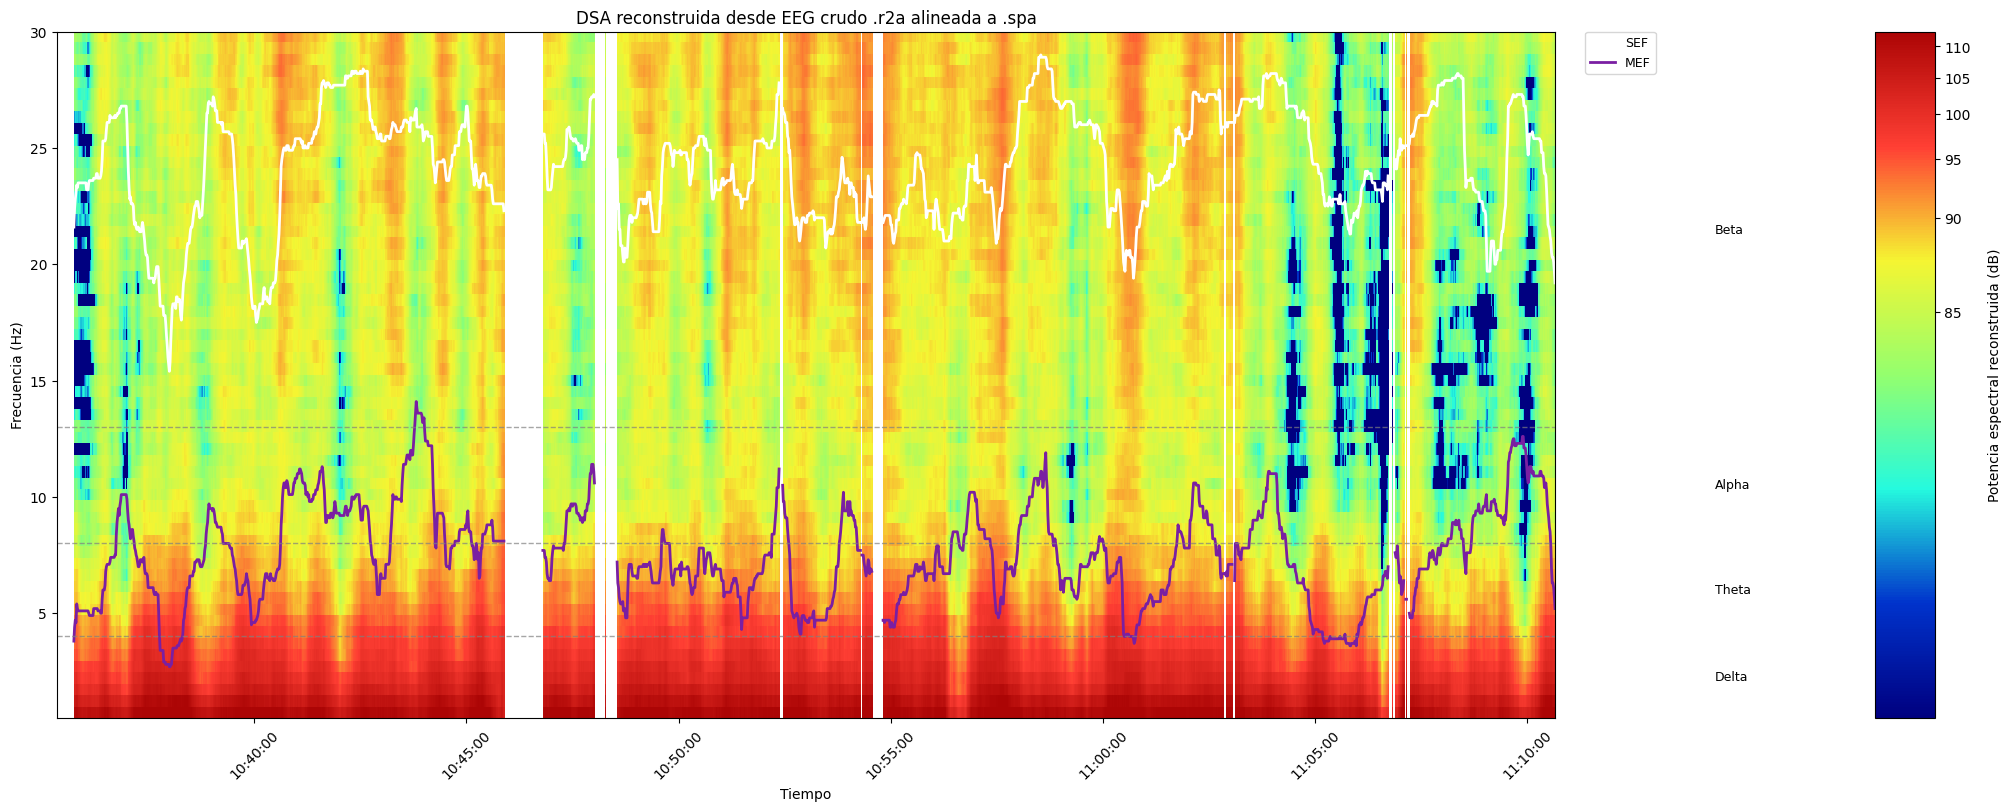

In [96]:
fig_shift, ax_shift, ax_band_shift, cax_shift = fun_plot.plot_dsa_con_sef_mef(
    tiempo=timeline_spa_unilat,
    frecuencias=dsa_eeg_suav_shift_plot.columns.astype(float),
    matriz=matriz_opt_desfase_full,
    norm=norm_opt_desfase_full,
    cmap=cmap_opt_desfase_full,
    df_merge=df_merge_eeg,
    titulo="DSA reconstruida desde EEG crudo .r2a alineada a .spa",
    etiqueta_colorbar="Potencia espectral reconstruida (dB)",
    mostrar_sef=True,
    mostrar_mef=True,
    mask_total=mask_comun
)

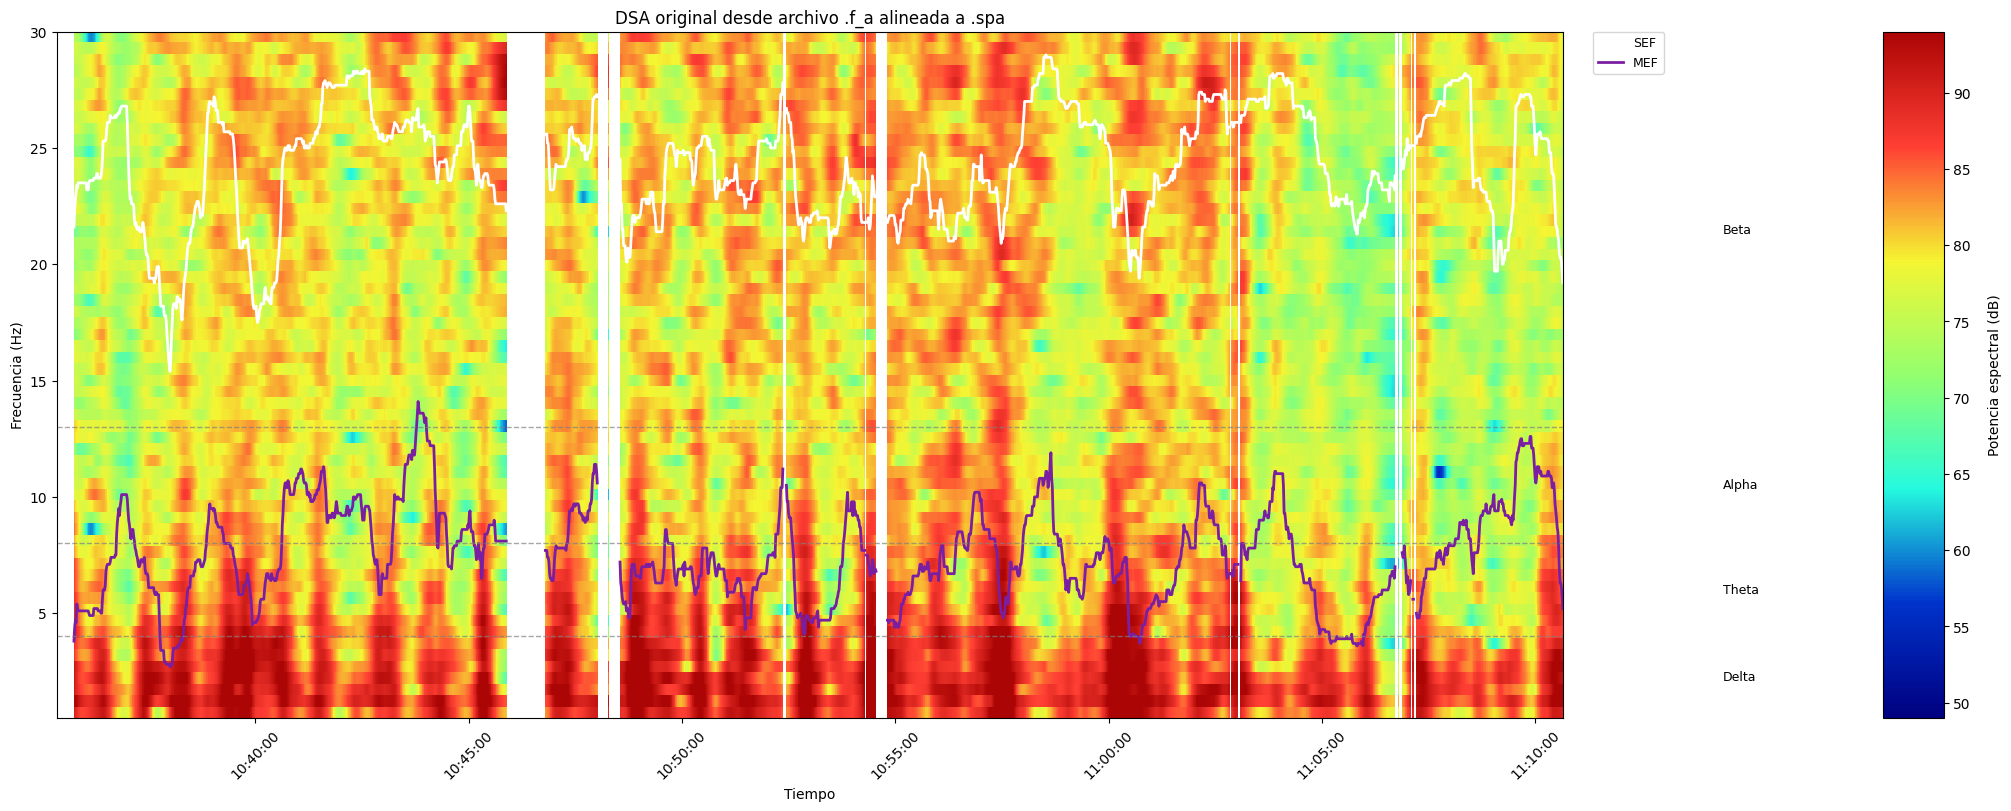

In [97]:
frecuencias_fa = dsa_fa_plot.columns.astype(float)

fig_fa, ax_fa, ax_band_fa, cax_fa = fun_plot.plot_dsa_con_sef_mef(
    tiempo=timeline_spa_unilat,
    frecuencias=frecuencias_fa,
    matriz=matriz_fa,
    norm=norm_fa,
    cmap=cmap_fa,
    df_merge=df_merge_fa,
    titulo="DSA original desde archivo .f_a alineada a .spa",
    etiqueta_colorbar="Potencia espectral (dB)",
    mostrar_sef=True,
    mostrar_mef=True,
    mask_total=mask_comun
)

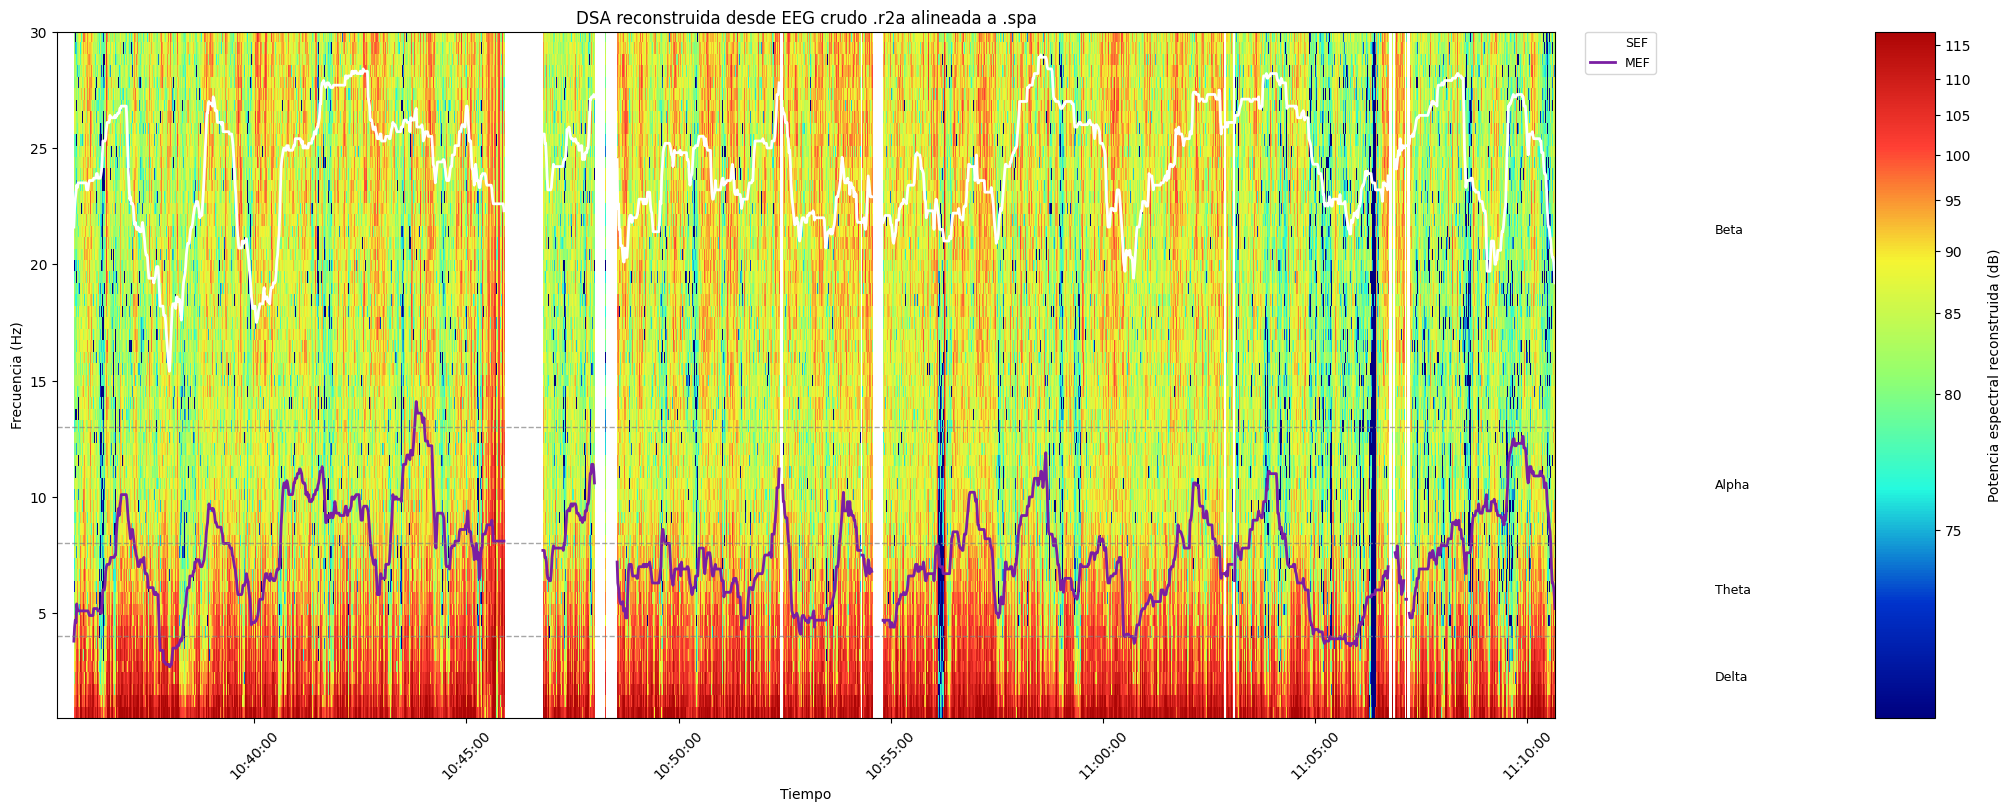

In [98]:
fig_eeg, ax_eeg, ax_band_eeg, cax_eeg = fun_plot.plot_dsa_con_sef_mef(
    tiempo=timeline_spa_unilat,
    frecuencias=dsa_eeg_plot.columns.astype(float),
    matriz=matriz_eeg,
    norm=norm_eeg,
    cmap=cmap_eeg,
    df_merge=df_merge_eeg,
    titulo="DSA reconstruida desde EEG crudo .r2a alineada a .spa",
    etiqueta_colorbar="Potencia espectral reconstruida (dB)",
    mostrar_sef=True,
    mostrar_mef=True,
    mask_total=mask_comun
)

# 2. Bilateral - Advanced

In [2]:


#archivo 17 horas
ruta_fa_bilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/bilateral/M-Py5D-04301923/DH04301923/L04301923.f_a"
ruta_spa_bilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/bilateral/M-Py5D-04301923/DH04301923/L04301923.spa"
ruta_ha_bilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/bilateral/M-Py5D-04301923/DH04301923/L04301923.h_a"
ruta_ta_bilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/bilateral/M-Py5D-04301923/DH04301923/L04301923.t_a"

archivo_r4a = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/bilateral/M-Py5D-04301923/DH04301923/L04301923.r4a" 


In [3]:
"""
ruta_fa_bilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/bilateral/L05141322/L05141322.f_a"
ruta_spa_bilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/bilateral/L05141322/L05141322.spa"
ruta_ha_bilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/bilateral/L05141322/L05141322.h_a"
ruta_ta_bilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/bilateral/L05141322/L05141322.t_a"

archivo_r4a = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/bilateral/L05141322/L05141322.r4a" 
"""

'\nruta_fa_bilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/bilateral/L05141322/L05141322.f_a"\nruta_spa_bilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/bilateral/L05141322/L05141322.spa"\nruta_ha_bilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/bilateral/L05141322/L05141322.h_a"\nruta_ta_bilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/bilateral/L05141322/L05141322.t_a"\n\narchivo_r4a = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/bilateral/L05141322/L05141322.r4a" \n'

In [4]:
"""
# este es para el bis vista que no tiene fa
ruta_spa_bilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_antiguo/L04141330/L04141330.spa"
ruta_ha_bilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_antiguo/L04141330/L04141330.h_a"
ruta_ta_bilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_antiguo/L04141330/L04141330.t_a"

archivo_r4a = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_antiguo/L04141330/L04141330.r4a"
"""

'\n# este es para el bis vista que no tiene fa\nruta_spa_bilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_antiguo/L04141330/L04141330.spa"\nruta_ha_bilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_antiguo/L04141330/L04141330.h_a"\nruta_ta_bilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_antiguo/L04141330/L04141330.t_a"\n\narchivo_r4a = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_antiguo/L04141330/L04141330.r4a"\n'

## 2. 1. Archivo Espectral .f_a

In [5]:
tiempo_fa_bilat, dsa_fa_L, dsa_fa_R = fau.cargar_fa_bilateral(
    ruta_fa_bilat,
    escalar_db=True
)

print("Dimensiones del archivo hemisferio izquierdo:", dsa_fa_L.shape)
print("Dimensiones del archivo hemisferio derecho:", dsa_fa_R.shape)

Dimensiones del archivo hemisferio izquierdo: (60890, 60)
Dimensiones del archivo hemisferio derecho: (60890, 60)


## 2. 2. Archivo variables procesadas .spa

In [6]:
df_spa_raw_bilat = fau.procesar_spa(ruta_spa_bilat)
df_spa_bilat = fun_dsa_b.limpiar_spa_bilateral(df_spa_raw_bilat)

print("Dimensiones del archivo procesado:", df_spa_bilat.shape)
print(df_spa_bilat.columns.tolist())
# display(df_spa_bilat.head())

Dimensiones del archivo procesado: (60889, 32)
['Time', 'SpSmooth', 'SR12_izq', 'SEF08_izq', 'MEDFRQ08_izq', 'BISBIT00_izq', 'DB13U01_izq', 'DB11U04_izq', 'B34U05_izq', 'TOTPOW08_izq', 'EMGLOW01_izq', 'SQI10_izq', 'IMPEDNCE_izq', 'ARTF2_izq', 'BURST_izq', 'ST_izq', 'SR12_der', 'SEF08_der', 'MEDFRQ08_der', 'BISBIT00_der', 'DB13U01_der', 'DB11U04_der', 'B34U05_der', 'TOTPOW08_der', 'EMGLOW01_der', 'SQI10_der', 'IMPEDNCE_der', 'ARTF2_der', 'BURST_der', 'ST_der', 'ASYM09', 'modo_spa']


In [7]:
# Extraer SpSmooth del .spa y traducirlo a segundos

valor_spsmooth_bilat, suavizado_spsmooth_bilat, dist_spsmooth_bilat = (
    fau.extraer_spsmooth_segundos(
        df_spa_bilat,
        verbose=True
    )
)

SpSmooth codificado más frecuente: 3
Suavizado espectral equivalente: 30 s

Distribución de valores SpSmooth:


SpSmooth
3    60889
Name: count, dtype: int64

### timeline oficial del .spa

In [8]:
timeline_spa_bilat = fun_dsa_b.preparar_timeline_spa(
    df_spa=df_spa_bilat,
    columna_time="Time",
    resolver_duplicados="last",
    verbose=True
)

Aviso: el .spa contiene 80 tiempos duplicados. Estrategia usada: last.
=== Timeline .spa ===
Inicio .spa: 2026-04-30 19:23:29
Fin .spa: 2026-05-01 12:18:16
N segundos .spa: 60809


### ajustar .f_a a la timeline del .spa

In [9]:
dsa_fa_L_spa = fun_dsa_b.ajustar_dsa_a_timeline_spa(
    tiempo_dsa=tiempo_fa_bilat,
    dsa=dsa_fa_L,
    timeline_spa=timeline_spa_bilat,
    nombre="f_a izquierdo",
    verbose=True
)

dsa_fa_R_spa = fun_dsa_b.ajustar_dsa_a_timeline_spa(
    tiempo_dsa=tiempo_fa_bilat,
    dsa=dsa_fa_R,
    timeline_spa=timeline_spa_bilat,
    nombre="f_a derecho",
    verbose=True
)


Aviso f_a izquierdo: hay tiempos duplicados. Se conserva el último.
=== Ajuste f_a izquierdo a timeline .spa ===
Inicio DSA original: 2026-04-30 19:23:28
Fin DSA original: 2026-05-01 12:18:16
Inicio .spa: 2026-04-30 19:23:29
Fin .spa: 2026-05-01 12:18:16
Filas DSA original: 60810
Filas timeline .spa: 60809
Filas DSA ajustada: 60809
Filas completamente NaN: 0
Aviso f_a derecho: hay tiempos duplicados. Se conserva el último.
=== Ajuste f_a derecho a timeline .spa ===
Inicio DSA original: 2026-04-30 19:23:28
Fin DSA original: 2026-05-01 12:18:16
Inicio .spa: 2026-04-30 19:23:29
Fin .spa: 2026-05-01 12:18:16
Filas DSA original: 60810
Filas timeline .spa: 60809
Filas DSA ajustada: 60809
Filas completamente NaN: 0


### Extraer .spa para cada hemisferio 

In [10]:
df_spa_L = fun_dsa_b.extraer_lado_spa_bilateral(
    df_spa_bilat,
    lado="izq",
    verbose=False
)

df_spa_R = fun_dsa_b.extraer_lado_spa_bilateral(
    df_spa_bilat,
    lado="der",
    verbose=False
)

###  Fusión .f_a y .spa

In [11]:
"""
Si hay dos paquetes con el mismo segundo, conservar el último suele ser razonable porque representa el estado más reciente dentro de ese segundo.

No usaría mean como opción principal porque hay columnas que no son realmente promediables
"""

df_merge_fa_L = fun_dsa.alinear_spa_con_tiempo(
    timeline_spa_bilat,
    df_spa_L,
    resolver_duplicados="last"
)

df_merge_fa_R = fun_dsa.alinear_spa_con_tiempo(
    timeline_spa_bilat,
    df_spa_R,
    resolver_duplicados="last"
)

# Curvas del BIS por hemisferio
sef_fa_L = df_merge_fa_L["SEF08"]
mef_fa_L = df_merge_fa_L["MEDFRQ08"]

sef_fa_R = df_merge_fa_R["SEF08"]
mef_fa_R = df_merge_fa_R["MEDFRQ08"]

Aviso: se han encontrado 80 tiempos duplicados en el .spa. Estrategia usada: last.
Aviso: se han encontrado 80 tiempos duplicados en el .spa. Estrategia usada: last.


In [12]:
print("timeline_spa_bilat:", len(timeline_spa_bilat))
print("df_merge_fa_L:", df_merge_fa_L.shape)
print("df_merge_fa_R:", df_merge_fa_R.shape)

timeline_spa_bilat: 60809
df_merge_fa_L: (60809, 9)
df_merge_fa_R: (60809, 9)


### Cabecera

In [13]:
num_canales_bil, fs_bil, pendiente_bil, offset_bil = fau.extraer_parametros_eeg(ruta_ha_bilat)
print("Parámetros extraídos con éxito:")
print(f" - Canales: {num_canales_bil}")
print(f" - Frecuencia (Hz): {fs_bil}")
print(f" - Pendiente (m): {pendiente_bil:.8f}")
print(f" - Offset (b): {offset_bil:.4f}")

Parámetros extraídos con éxito:
 - Canales: 4
 - Frecuencia (Hz): 128
 - Pendiente (m): 0.05000000
 - Offset (b): -3234.0000


## 2. 3. Archivo ondas crudas .r4a

In [14]:
df_eeg_bilateral = fun_dsa_b.leer_r4a(
    archivo_r4a, 
    pendiente_bil,
    offset_bil, 
    fs=fs_bil)

In [15]:
# Alinear raw al tamaño y timeline del .spa
df_eeg_bilat_recortado, timeline_spa_bilat, info_alineacion = (
    fun_dsa_b.recortar_raw_segun_ta_y_spa(
        df_raw=df_eeg_bilateral,
        ruta_ta=ruta_ta_bilat,
        df_spa=df_spa_bilat,
        columna_time="Time",
        fs=fs_bil,
        resolver_duplicados="last",
        verbose=True
    )
)

# Usar el inicio del .spa como inicio de la DSA reconstruida
hora_inicio = timeline_spa_bilat.iloc[0]

print("Raw bilateral original:", df_eeg_bilateral.shape)
print("Raw bilateral recortado:", df_eeg_bilat_recortado.shape)
print("Timeline SPA:", len(timeline_spa_bilat))

Aviso: el .spa contiene 80 tiempos duplicados. Estrategia usada: last.
=== Timeline .spa ===
Inicio .spa: 2026-04-30 19:23:29
Fin .spa: 2026-05-01 12:18:16
N segundos .spa: 60809
=== Alineación raw a timeline .spa ===
Inicio raw (.t_a): 2026-04-30 19:23:28
Inicio .spa: 2026-04-30 19:23:29
Fin .spa: 2026-05-01 12:18:16
Desfase spa - raw: 1.0 s
Acción inicio: recorte_inicio
Segundos objetivo .spa: 60809
Muestras objetivo: 7783552
Muestras raw originales: 7793920
Muestras recortadas inicio: 128
Muestras NaN inicio: 0
Muestras recortadas final: 0
Muestras NaN final: 0
Muestras raw alineado: 7783552
Duración raw alineado: 60809.0 s
Raw bilateral original: (7793920, 9)
Raw bilateral recortado: (7783552, 9)
Timeline SPA: 60809


### 2. 3. 1. Reconstrucción

In [16]:
# ============================================================
# Reconstrucción DSA por canal
# ============================================================

ventana_welch_s = 2
paso_welch_s = 1

df_dsa_canal1, frecuencias_c1 = fun_dsa.crear_matriz_dsa_fft_welch_desde_eeg(
    df_eeg_bilat_recortado,
    "canal_1_uV",
    fs=fs_bil,
    ventana_seg=ventana_welch_s,
    paso_seg=paso_welch_s,
    fmin=0.5,
    fmax=30.0,
    paso_freq=0.5,
    modo="densidad",
    tiempo_referencia="centro"
)

df_dsa_canal2, _ = fun_dsa.crear_matriz_dsa_fft_welch_desde_eeg(
    df_eeg_bilat_recortado,
    "canal_2_uV",
    fs=fs_bil,
    ventana_seg=ventana_welch_s,
    paso_seg=paso_welch_s,
    fmin=0.5,
    fmax=30.0,
    paso_freq=0.5,
    modo="densidad",
    tiempo_referencia="centro"
)

df_dsa_canal3, _ = fun_dsa.crear_matriz_dsa_fft_welch_desde_eeg(
    df_eeg_bilat_recortado,
    "canal_3_uV",
    fs=fs_bil,
    ventana_seg=ventana_welch_s,
    paso_seg=paso_welch_s,
    fmin=0.5,
    fmax=30.0,
    paso_freq=0.5,
    modo="densidad",
    tiempo_referencia="centro"
)

df_dsa_canal4, _ = fun_dsa.crear_matriz_dsa_fft_welch_desde_eeg(
    df_eeg_bilat_recortado,
    "canal_4_uV",
    fs=fs_bil,
    ventana_seg=ventana_welch_s,
    paso_seg=paso_welch_s,
    fmin=0.5,
    fmax=30.0,
    paso_freq=0.5,
    modo="densidad",
    tiempo_referencia="centro"
)

In [17]:
# Combinación por hemisferio en escala lineal

cols_freq = [c for c in df_dsa_canal1.columns if c != "tiempo_s"]

# Izquierda: canal 1 + canal 2
pot_media_izq = (
    df_dsa_canal1[cols_freq].to_numpy(dtype=float) +
    df_dsa_canal2[cols_freq].to_numpy(dtype=float)
) / 2

# Derecha: canal 3 + canal 4
pot_media_der = (
    df_dsa_canal3[cols_freq].to_numpy(dtype=float) +
    df_dsa_canal4[cols_freq].to_numpy(dtype=float)
) / 2

df_dsa_izq = df_dsa_canal1.copy()
df_dsa_der = df_dsa_canal3.copy()

In [18]:
# Conversión a dB para visualización

ref_potencia = 0.0001

df_dsa_izq[cols_freq] = 10 * np.log10(
    (pot_media_izq + 1e-12) / (ref_potencia ** 2)
)

df_dsa_der[cols_freq] = 10 * np.log10(
    (pot_media_der + 1e-12) / (ref_potencia ** 2)
)

### 2. 3. 2. Adaptación temporal, máscara y plot de DSA EEG

In [19]:
# ============================================================
# Adaptación temporal inicial de la DSA reconstruida
# ============================================================

hora_inicio = timeline_spa_bilat.iloc[0]

tiempo_eeg_bilat_tmp, dsa_eeg_izq_tmp = fun_dsa.adaptar_dsa_reconstruida_para_plot(
    df_dsa=df_dsa_izq,
    frecuencias=frecuencias_c1,
    hora_inicio=hora_inicio,
    insertar_fila_inicial_nan=True
)

_, dsa_eeg_der_tmp = fun_dsa.adaptar_dsa_reconstruida_para_plot(
    df_dsa=df_dsa_der,
    frecuencias=frecuencias_c1,
    hora_inicio=hora_inicio,
    insertar_fila_inicial_nan=True
)

In [20]:
# ============================================================
# Ajustar reconstruida a la timeline oficial del .spa
# ============================================================

dsa_eeg_izq_spa = fun_dsa_b.ajustar_dsa_a_timeline_spa(
    tiempo_dsa=tiempo_eeg_bilat_tmp,
    dsa=dsa_eeg_izq_tmp,
    timeline_spa=timeline_spa_bilat,
    nombre="DSA EEG reconstruida izquierda",
    verbose=True
)

dsa_eeg_der_spa = fun_dsa_b.ajustar_dsa_a_timeline_spa(
    tiempo_dsa=tiempo_eeg_bilat_tmp,
    dsa=dsa_eeg_der_tmp,
    timeline_spa=timeline_spa_bilat,
    nombre="DSA EEG reconstruida derecha",
    verbose=True
)

# Desde aquí, el tiempo oficial de la reconstruida también es el del .spa
tiempo_eeg_bilat = timeline_spa_bilat.copy()

=== Ajuste DSA EEG reconstruida izquierda a timeline .spa ===
Inicio DSA original: 2026-04-30 19:23:29
Fin DSA original: 2026-05-01 12:16:57
Inicio .spa: 2026-04-30 19:23:29
Fin .spa: 2026-05-01 12:18:16
Filas DSA original: 60809
Filas timeline .spa: 60809
Filas DSA ajustada: 60809
Filas completamente NaN: 80
=== Ajuste DSA EEG reconstruida derecha a timeline .spa ===
Inicio DSA original: 2026-04-30 19:23:29
Fin DSA original: 2026-05-01 12:16:57
Inicio .spa: 2026-04-30 19:23:29
Fin .spa: 2026-05-01 12:18:16
Filas DSA original: 60809
Filas timeline .spa: 60809
Filas DSA ajustada: 60809
Filas completamente NaN: 80


In [21]:
# Merge del .spa para la reconstruida

df_merge_eeg_izq = fun_dsa.alinear_spa_con_tiempo(
    tiempo=timeline_spa_bilat,
    df_spa=df_spa_L,
    resolver_duplicados="last"
)

df_merge_eeg_der = fun_dsa.alinear_spa_con_tiempo(
    tiempo=timeline_spa_bilat,
    df_spa=df_spa_R,
    resolver_duplicados="last"
)

Aviso: se han encontrado 80 tiempos duplicados en el .spa. Estrategia usada: last.
Aviso: se han encontrado 80 tiempos duplicados en el .spa. Estrategia usada: last.


### Máscaras de calidad bilateral - común

In [22]:
_, mask_comun_L = fun_dsa.preparar_dsa_con_mask(
    tiempo=timeline_spa_bilat,
    dsa=dsa_eeg_izq_spa,
    df_merge=df_merge_eeg_izq,
    umbral_sqi=15,
    umbral_ceros=0.9,
    incluir_filas_nan=True
)

_, mask_comun_R = fun_dsa.preparar_dsa_con_mask(
    tiempo=timeline_spa_bilat,
    dsa=dsa_eeg_der_spa,
    df_merge=df_merge_eeg_der,
    umbral_sqi=15,
    umbral_ceros=0.9,
    incluir_filas_nan=True
)

print(f"Filas totales izquierda:", len(mask_comun_L))
print(f"Filas totales derecha:", len(mask_comun_R))

print(f"\nFilas enmascaradas izquierda:", mask_comun_L.sum())
print("Filas enmascaradas derecha:", mask_comun_R.sum())

print(f"\nFilas válidas izquierda:", (~mask_comun_L).sum())
print("Filas válidas derecha:", (~mask_comun_R).sum())

Filas totales izquierda: 60809
Filas totales derecha: 60809

Filas enmascaradas izquierda: 3972
Filas enmascaradas derecha: 5367

Filas válidas izquierda: 56837
Filas válidas derecha: 55442


#### Añadir posibles huecos del .f_a, si existe archivo espectral

In [23]:
# Filas completamente NaN del .f_a ajustado al .spa (comprobación adicional por si acaso)
mask_fa_nan_L = dsa_fa_L_spa.isna().all(axis=1)
mask_fa_nan_R = dsa_fa_R_spa.isna().all(axis=1)

mask_comun_L = mask_comun_L | mask_fa_nan_L
mask_comun_R = mask_comun_R | mask_fa_nan_R

In [24]:
print("NaN f_a L:", mask_fa_nan_L.sum())
print("NaN f_a R:", mask_fa_nan_R.sum())

print("\nFilas enmascaradas finales L:", mask_comun_L.sum())
print("Filas enmascaradas finales R:", mask_comun_R.sum())

print("\nFilas válidas finales L:", (~mask_comun_L).sum())
print("Filas válidas finales R:", (~mask_comun_R).sum())

NaN f_a L: 0
NaN f_a R: 0

Filas enmascaradas finales L: 3972
Filas enmascaradas finales R: 5367

Filas válidas finales L: 56837
Filas válidas finales R: 55442


#### Aplicación

In [25]:
# Aplicar máscara común para que izquierda y derecha tengan bandas blancas alineadas

# -------------------------------------- Para EEG ----------------------------------
dsa_eeg_izq_plot = dsa_eeg_izq_spa.copy()
dsa_eeg_der_plot = dsa_eeg_der_spa.copy()

dsa_eeg_izq_plot.loc[mask_comun_L.values, :] = np.nan
dsa_eeg_der_plot.loc[mask_comun_R.values, :] = np.nan

In [26]:
# -------------------------------------- Para FA ----------------------------------
dsa_plot_fa_L_mask = dsa_fa_L_spa.copy()
dsa_plot_fa_R_mask = dsa_fa_R_spa.copy()

dsa_plot_fa_L_mask.loc[mask_comun_L.values, :] = np.nan
dsa_plot_fa_R_mask.loc[mask_comun_R.values, :] = np.nan

#### Comprobación

In [27]:
# ============================================================
# Comprobación de bandas blancas tras aplicar máscaras por hemisferio
# ============================================================

# 1. Detectar filas completamente blancas en cada matriz
mask_blanca_eeg_L = dsa_eeg_izq_plot.isna().all(axis=1)
mask_blanca_eeg_R = dsa_eeg_der_plot.isna().all(axis=1)

mask_blanca_fa_L = dsa_plot_fa_L_mask.isna().all(axis=1)
mask_blanca_fa_R = dsa_plot_fa_R_mask.isna().all(axis=1)


# 2. Comprobar que las bandas blancas coinciden con la máscara aplicada
print("=== COMPROBACIÓN IZQUIERDA ===")
print("EEG L coincide con mask_comun_L:", (mask_blanca_eeg_L.values == mask_comun_L.values).all())
print("FA  L coincide con mask_comun_L:", (mask_blanca_fa_L.values == mask_comun_L.values).all())

print("Bandas blancas EEG L:", mask_blanca_eeg_L.sum())
print("Bandas blancas FA  L:", mask_blanca_fa_L.sum())
print("Filas en mask_comun_L:", mask_comun_L.sum())

print("Diferencias EEG L vs máscara:", (mask_blanca_eeg_L.values != mask_comun_L.values).sum())
print("Diferencias FA  L vs máscara:", (mask_blanca_fa_L.values != mask_comun_L.values).sum())


print("\n=== COMPROBACIÓN DERECHA ===")
print("EEG R coincide con mask_comun_R:", (mask_blanca_eeg_R.values == mask_comun_R.values).all())
print("FA  R coincide con mask_comun_R:", (mask_blanca_fa_R.values == mask_comun_R.values).all())

print("Bandas blancas EEG R:", mask_blanca_eeg_R.sum())
print("Bandas blancas FA  R:", mask_blanca_fa_R.sum())
print("Filas en mask_comun_R:", mask_comun_R.sum())

print("Diferencias EEG R vs máscara:", (mask_blanca_eeg_R.values != mask_comun_R.values).sum())
print("Diferencias FA  R vs máscara:", (mask_blanca_fa_R.values != mask_comun_R.values).sum())


# 3. Tabla para localizar posibles diferencias
df_check_blancas = pd.DataFrame({
    "Time": timeline_spa_bilat.reset_index(drop=True),

    "mask_comun_L": mask_comun_L.reset_index(drop=True),
    "blanca_eeg_L": mask_blanca_eeg_L.reset_index(drop=True),
    "blanca_fa_L": mask_blanca_fa_L.reset_index(drop=True),

    "mask_comun_R": mask_comun_R.reset_index(drop=True),
    "blanca_eeg_R": mask_blanca_eeg_R.reset_index(drop=True),
    "blanca_fa_R": mask_blanca_fa_R.reset_index(drop=True),
})

df_check_blancas["diff_eeg_L"] = df_check_blancas["mask_comun_L"] != df_check_blancas["blanca_eeg_L"]
df_check_blancas["diff_fa_L"] = df_check_blancas["mask_comun_L"] != df_check_blancas["blanca_fa_L"]

df_check_blancas["diff_eeg_R"] = df_check_blancas["mask_comun_R"] != df_check_blancas["blanca_eeg_R"]
df_check_blancas["diff_fa_R"] = df_check_blancas["mask_comun_R"] != df_check_blancas["blanca_fa_R"]


# 4. Mostrar solo filas problemáticas, si las hay
df_diferencias_blancas = df_check_blancas[
    df_check_blancas[
        ["diff_eeg_L", "diff_fa_L", "diff_eeg_R", "diff_fa_R"]
    ].any(axis=1)
]

print("\nNúmero total de filas con alguna diferencia:", len(df_diferencias_blancas))

display(df_diferencias_blancas.head(50))

=== COMPROBACIÓN IZQUIERDA ===
EEG L coincide con mask_comun_L: True
FA  L coincide con mask_comun_L: True
Bandas blancas EEG L: 3972
Bandas blancas FA  L: 3972
Filas en mask_comun_L: 3972
Diferencias EEG L vs máscara: 0
Diferencias FA  L vs máscara: 0

=== COMPROBACIÓN DERECHA ===
EEG R coincide con mask_comun_R: True
FA  R coincide con mask_comun_R: True
Bandas blancas EEG R: 5367
Bandas blancas FA  R: 5367
Filas en mask_comun_R: 5367
Diferencias EEG R vs máscara: 0
Diferencias FA  R vs máscara: 0

Número total de filas con alguna diferencia: 0


,Time,mask_comun_L,blanca_eeg_L,blanca_fa_L,mask_comun_R,blanca_eeg_R,blanca_fa_R,diff_eeg_L,diff_fa_L,diff_eeg_R,diff_fa_R


### 2. 3. 3. Preparar escala de color de f_a y eeg reconstruida

In [28]:
# -------------------------------------- Para EEG ----------------------------------
matriz_eeg_izq, matriz_eeg_der, vmin_eeg, vmax_eeg, norm_eeg_bilat, cmap_eeg_bilat = (
    fun_dsa_b.preparar_escala_color_dsa_bilateral(
        dsa_eeg_izq_plot,
        dsa_eeg_der_plot,
        gamma=0.55
    )
)

print("Reconstruida bilateral")
print("vmin:", vmin_eeg)
print("vmax:", vmax_eeg)

Reconstruida bilateral
vmin: 52.239236228988894
vmax: 108.68690141443938


In [29]:
# -------------------------------------- Para FA ----------------------------------
matriz_fa_L, matriz_fa_R, vmin_fa, vmax_fa, norm_fa_bilat, cmap_fa_bilat = (
    fun_dsa_b.preparar_escala_color_dsa_bilateral(
        dsa_plot_fa_L_mask,
        dsa_plot_fa_R_mask,
        vmin=49,
        vmax=94,
        gamma=1
    )
)


### 2. 3. 4. Visualizar reconstruidas desde .r4a

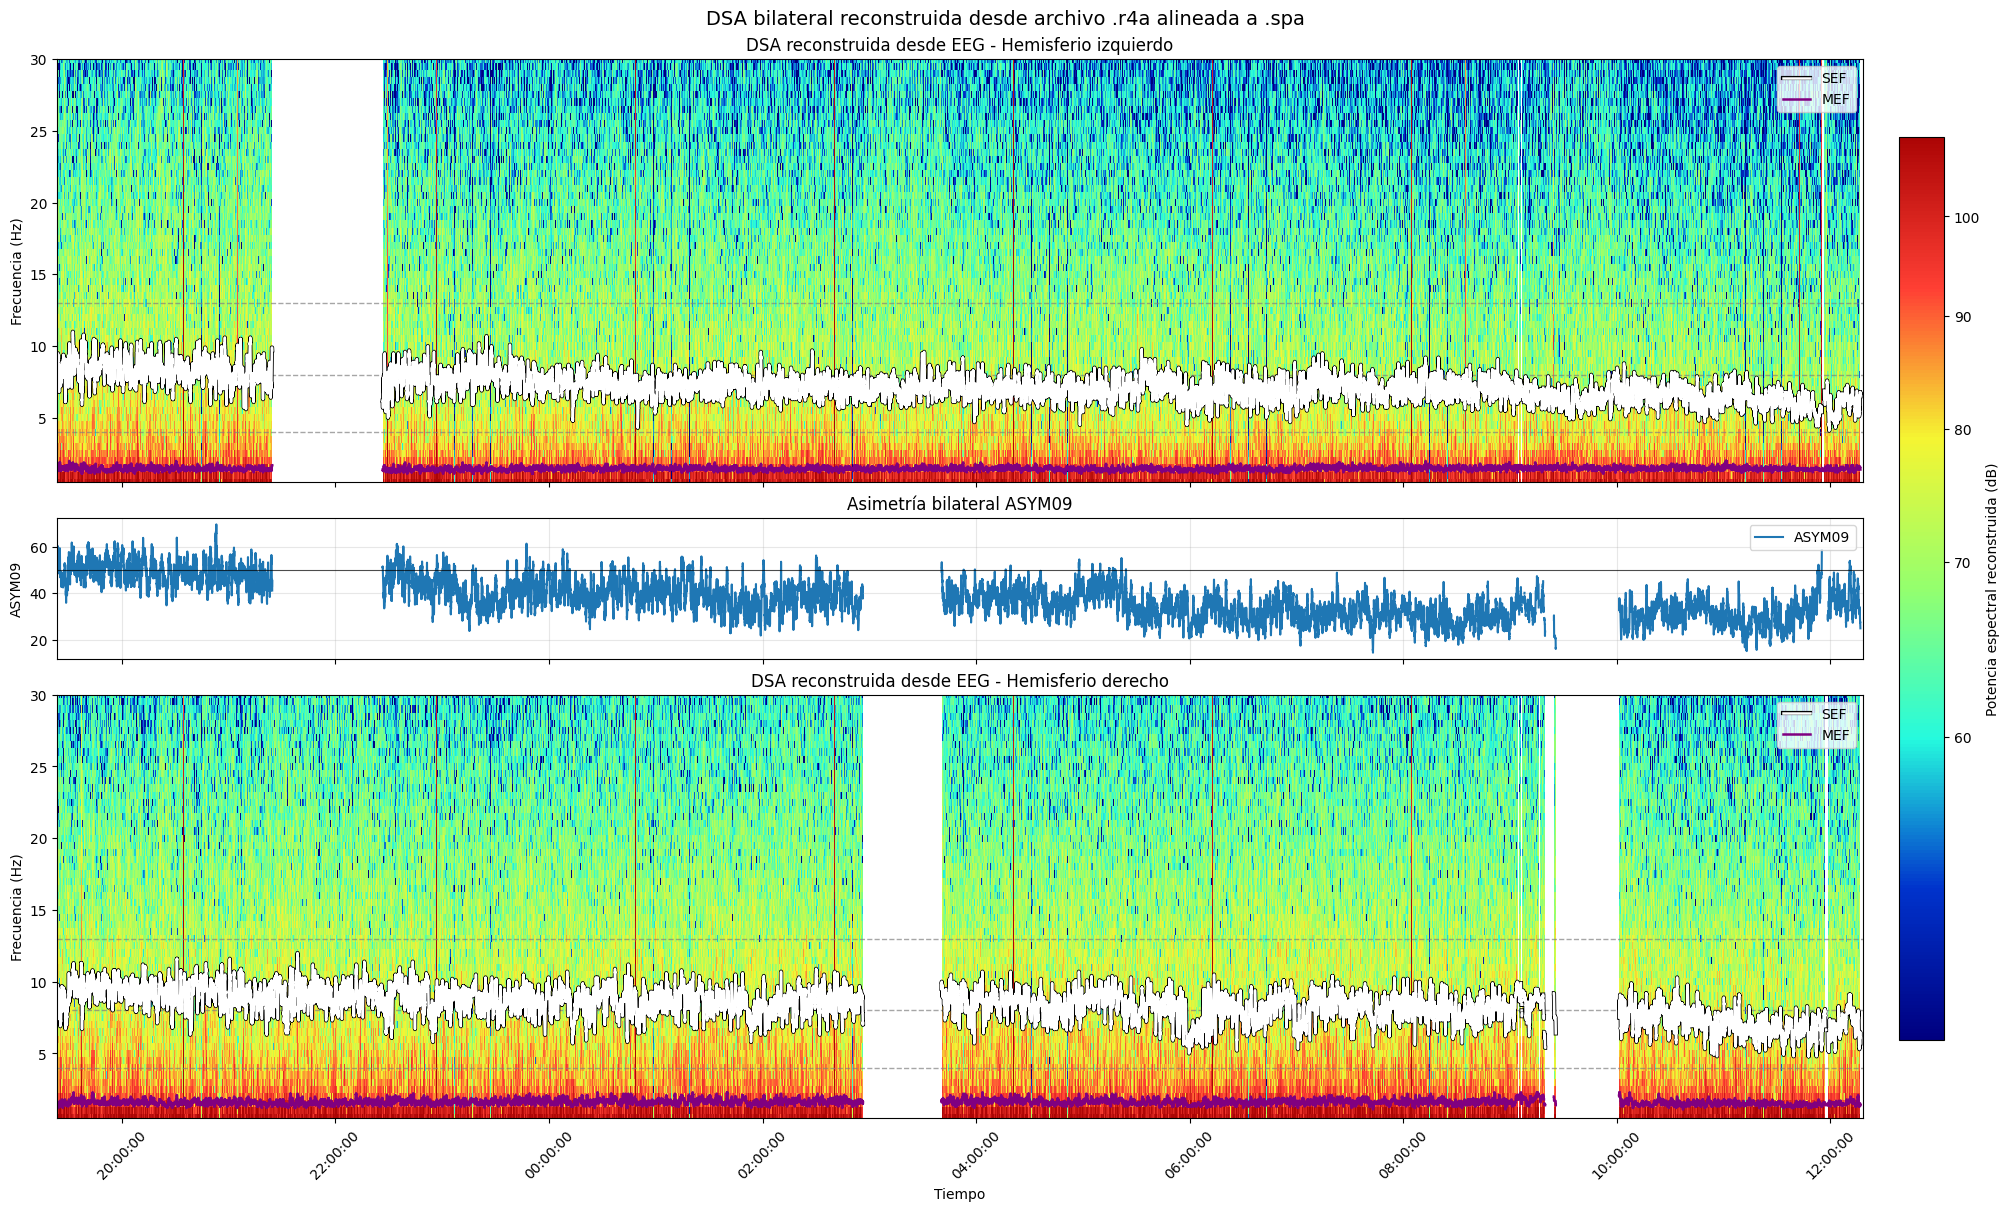

In [30]:
fig_eeg, axes_eeg = fun_plot.plot_dsa_bilateral_con_sef_mef(
    tiempo=timeline_spa_bilat,
    frecuencias=dsa_eeg_izq_plot.columns.astype(float),
    matriz_izq=matriz_eeg_izq,
    matriz_der=matriz_eeg_der,
    norm=norm_eeg_bilat,
    cmap=cmap_eeg_bilat,
    df_merge_izq=df_merge_eeg_izq,
    df_merge_der=df_merge_eeg_der,
    mask_izq=mask_comun_L,
    mask_der=mask_comun_R,
    asimetria=df_merge_eeg_izq["ASYM09"] if "ASYM09" in df_merge_eeg_izq.columns else None,
    titulo_izq="DSA reconstruida desde EEG - Hemisferio izquierdo",
    titulo_der="DSA reconstruida desde EEG - Hemisferio derecho",
    titulo_general="DSA bilateral reconstruida desde archivo .r4a alineada a .spa",
    etiqueta_colorbar="Potencia espectral reconstruida (dB)"
)

### Máscaras y visualización - .f_a 

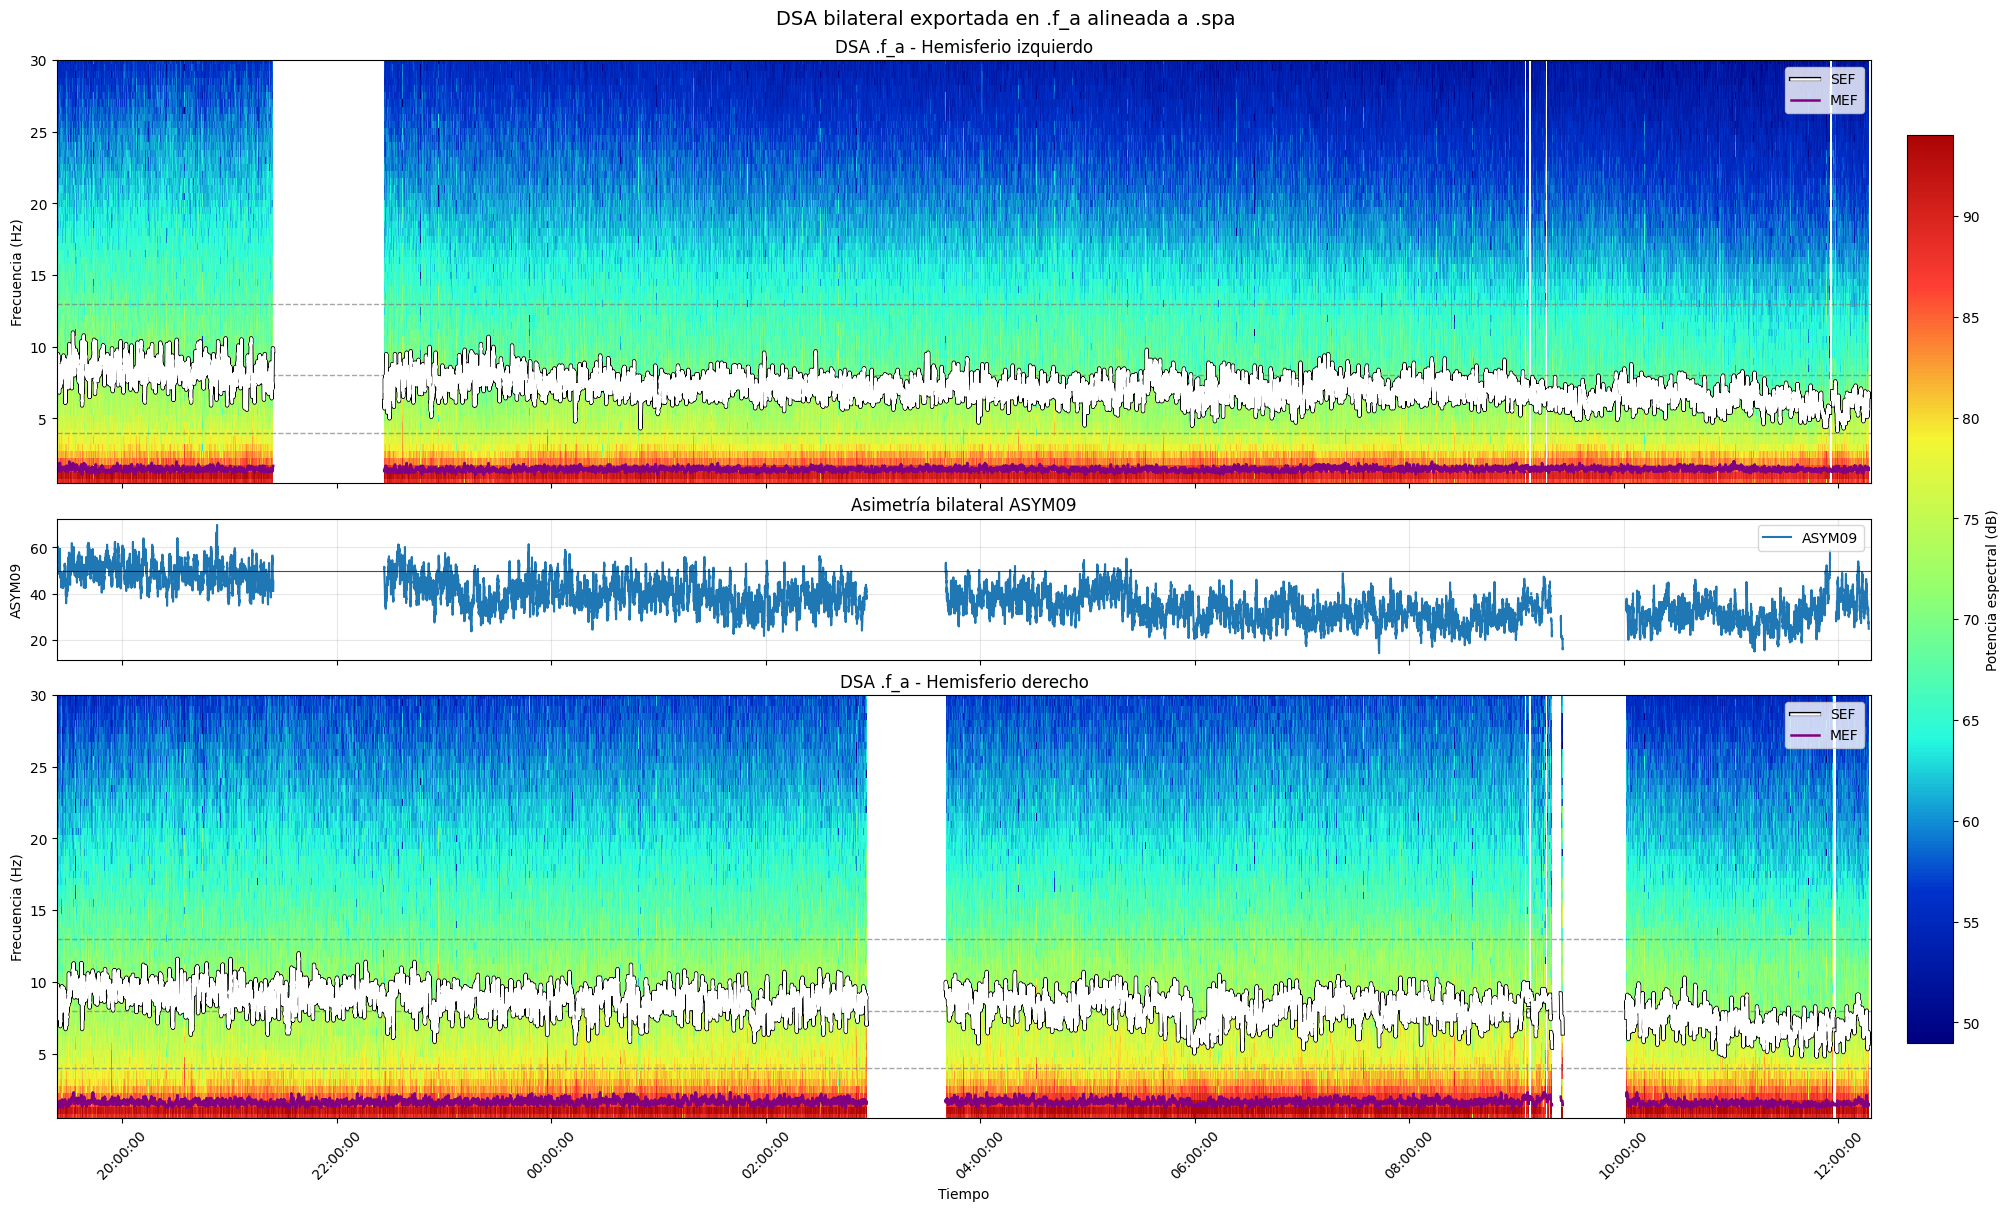

In [31]:
frecuencias_fa = dsa_plot_fa_L_mask.columns.astype(float)

fig_fa, axes_fa = fun_plot.plot_dsa_bilateral_con_sef_mef(
    tiempo=timeline_spa_bilat,
    frecuencias=frecuencias_fa,
    matriz_izq=matriz_fa_L,
    matriz_der=matriz_fa_R,
    norm=norm_fa_bilat,
    cmap=cmap_fa_bilat,
    df_merge_izq=df_merge_fa_L,
    df_merge_der=df_merge_fa_R,
    mask_izq=mask_comun_L,
    mask_der=mask_comun_R,
    asimetria=df_merge_fa_L["ASYM09"],
    titulo_izq="DSA .f_a - Hemisferio izquierdo",
    titulo_der="DSA .f_a - Hemisferio derecho",
    titulo_general="DSA bilateral exportada en .f_a alineada a .spa",
    etiqueta_colorbar="Potencia espectral (dB)"
)

In [32]:
print("timeline_spa_bilat:", len(timeline_spa_bilat))

print("\nFA L ajustado:", dsa_fa_L_spa.shape)
print("FA R ajustado:", dsa_fa_R_spa.shape)

print("\nEEG L ajustado:", dsa_eeg_izq_spa.shape)
print("EEG R ajustado:", dsa_eeg_der_spa.shape)

print("\nmerge EEG L:", df_merge_eeg_izq.shape)
print("merge EEG R:", df_merge_eeg_der.shape)

print("\nplot EEG L:", dsa_eeg_izq_plot.shape)
print("plot EEG R:", dsa_eeg_der_plot.shape)

timeline_spa_bilat: 60809

FA L ajustado: (60809, 60)
FA R ajustado: (60809, 60)

EEG L ajustado: (60809, 60)
EEG R ajustado: (60809, 60)

merge EEG L: (60809, 9)
merge EEG R: (60809, 9)

plot EEG L: (60809, 60)
plot EEG R: (60809, 60)


In [33]:
cols_freq_eeg_L = [c for c in dsa_eeg_izq_plot.columns]

print("Mínimos y máximos hemisferio izquierdo - RECONSTRUCCIÓN")
print(np.nanmin(dsa_eeg_izq_plot[cols_freq_eeg_L].values))
print(np.nanmax(dsa_eeg_izq_plot[cols_freq_eeg_L].values))

print("\nPercentiles mínimos y máximos hemisferio izquierdo")
print(np.nanpercentile(dsa_eeg_izq_plot[cols_freq_eeg_L].values, 2))
print(np.nanpercentile(dsa_eeg_izq_plot[cols_freq_eeg_L].values, 99.5))

Mínimos y máximos hemisferio izquierdo - RECONSTRUCCIÓN
27.088196207112638
138.35507109123324

Percentiles mínimos y máximos hemisferio izquierdo
51.01816322417075
107.30439861920455


In [34]:
cols_freq_fa_L = [c for c in dsa_plot_fa_L_mask.columns]

print("Mínimos y máximos hemisferio izquierdo - FA")
print(np.nanmin(dsa_plot_fa_L_mask[cols_freq_fa_L].values))
print(np.nanmax(dsa_plot_fa_L_mask[cols_freq_fa_L].values))

print("\nPercentiles mínimos y máximos hemisferio izquierdo")
print(np.nanpercentile(dsa_plot_fa_L_mask[cols_freq_fa_L].values, 2))
print(np.nanpercentile(dsa_plot_fa_L_mask[cols_freq_fa_L].values, 99.5))

Mínimos y máximos hemisferio izquierdo - FA
35.25
97.08

Percentiles mínimos y máximos hemisferio izquierdo
52.54
91.19


In [35]:
cols_freq_eeg_R = [c for c in dsa_eeg_der_plot.columns]

print("Mínimos y máximos hemisferio derecho - RECONSTRUCCIÓN")
print(np.nanmin(dsa_eeg_der_plot[cols_freq_eeg_R].values))
print(np.nanmax(dsa_eeg_der_plot[cols_freq_eeg_R].values))

print("\nPercentiles mínimos y máximos hemisferio derecho")
print(np.nanpercentile(dsa_eeg_der_plot[cols_freq_eeg_R].values, 2))
print(np.nanpercentile(dsa_eeg_der_plot[cols_freq_eeg_R].values, 99.5))

Mínimos y máximos hemisferio derecho - RECONSTRUCCIÓN
22.6978590410286
138.76293435642336

Percentiles mínimos y máximos hemisferio derecho
54.18712366574844
109.63922151204402


In [36]:
cols_freq_fa_R = [c for c in dsa_plot_fa_R_mask.columns]

print("Mínimos y máximos hemisferio derecho - FA")
print(np.nanmin(dsa_plot_fa_R_mask[cols_freq_fa_R].values))
print(np.nanmax(dsa_plot_fa_R_mask[cols_freq_fa_R].values))

print("\nPercentiles mínimos y máximos hemisferio derecho")
print(np.nanpercentile(dsa_plot_fa_R_mask[cols_freq_fa_R].values, 2))
print(np.nanpercentile(dsa_plot_fa_R_mask[cols_freq_fa_R].values, 99.5))

Mínimos y máximos hemisferio derecho - FA
35.03
101.04

Percentiles mínimos y máximos hemisferio derecho
56.09
93.35


# Métricas y comparación

``` python

# Para métricas base:
dsa_eeg_izq_plot      vs dsa_plot_fa_L_mask
dsa_eeg_der_plot      vs dsa_plot_fa_R_mask

# Para suavizado:
dsa_eeg_izq_spa  vs  dsa_fa_L_spa
dsa_eeg_der_spa  vs  dsa_fa_R_spa

# Para visualizar:
tiempo = timeline_spa_bilat
```

In [37]:
# ============================================================
# Comparación base bilateral: EEG reconstruida vs .f_a
# ============================================================

# Izquierda
dsa_eeg_L_comp, dsa_fa_L_comp = fun_dsa.preparar_matrices_para_comparacion(
    dsa_eeg_izq_plot,
    dsa_plot_fa_L_mask
)

dsa_eeg_L_z = fun_dsa.zscore_global(dsa_eeg_L_comp)
dsa_fa_L_z = fun_dsa.zscore_global(dsa_fa_L_comp)

metricas_base_L = fun_dsa.comparar_dsa_global(
    dsa_eeg_L_z,
    dsa_fa_L_z
)


# Derecha
dsa_eeg_R_comp, dsa_fa_R_comp = fun_dsa.preparar_matrices_para_comparacion(
    dsa_eeg_der_plot,
    dsa_plot_fa_R_mask
)

dsa_eeg_R_z = fun_dsa.zscore_global(dsa_eeg_R_comp)
dsa_fa_R_z = fun_dsa.zscore_global(dsa_fa_R_comp)

metricas_base_R = fun_dsa.comparar_dsa_global(
    dsa_eeg_R_z,
    dsa_fa_R_z
)


# Resumen
# compara las matrices ya enmascaradas
df_metricas_base_bilat = pd.DataFrame([
    {"hemisferio": "izquierdo",
        **metricas_base_L},
    {"hemisferio": "derecho",
        **metricas_base_R}
])

display(df_metricas_base_bilat)

,hemisferio,n_valores_comparados,MAE,RMSE,bias_B_menos_A,Pearson,Spearman
0,izquierdo,3410220,0.412398,0.571746,2.335864e-15,0.836553,0.805014
1,derecho,3326520,0.405809,0.542346,7.543234e-15,0.852930,0.825622


In [38]:
# ============================================================
# Correlación por frecuencia bilateral
# ============================================================

df_corr_freq_L = fun_dsa.correlacion_por_frecuencia(
    dsa_eeg_L_z,
    dsa_fa_L_z
)

df_corr_freq_L["hemisferio"] = "izquierdo"


df_corr_freq_R = fun_dsa.correlacion_por_frecuencia(
    dsa_eeg_R_z,
    dsa_fa_R_z
)

df_corr_freq_R["hemisferio"] = "derecho"


df_corr_freq_bilat = pd.concat(
    [df_corr_freq_L, df_corr_freq_R],
    ignore_index=True
)

display(df_corr_freq_bilat.head())

,frecuencia_Hz,correlacion,hemisferio
0,0.5,0.104658,izquierdo
1,1.0,0.087387,izquierdo
2,1.5,0.080315,izquierdo
3,2.0,0.058093,izquierdo
4,2.5,0.057286,izquierdo


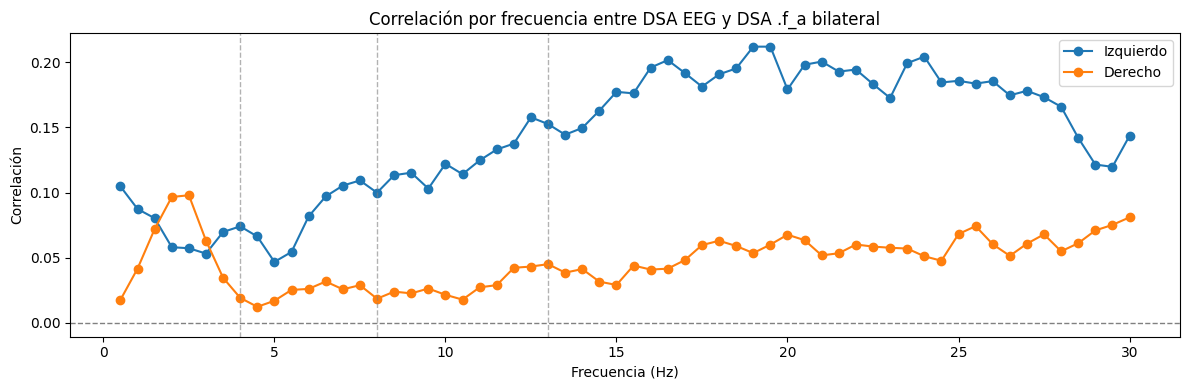

In [39]:
plt.figure(figsize=(12, 4))

plt.plot(
    df_corr_freq_L["frecuencia_Hz"],
    df_corr_freq_L["correlacion"],
    marker="o",
    label="Izquierdo"
)

plt.plot(
    df_corr_freq_R["frecuencia_Hz"],
    df_corr_freq_R["correlacion"],
    marker="o",
    label="Derecho"
)

for f in [4, 8, 13]:
    plt.axvline(f, color="gray", linestyle="--", linewidth=1, alpha=0.6)

plt.axhline(0, color="gray", linestyle="--", linewidth=1)

plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Correlación")
plt.title("Correlación por frecuencia entre DSA EEG y DSA .f_a bilateral")
plt.legend()
plt.tight_layout()
plt.show()

### Suavizado + shift

In [40]:
ventanas_sp_smooth_probar = [1, 5, 10, 30, 60]

print("Ventanas a probar:", ventanas_sp_smooth_probar)
print("Ventana indicada por SpSmooth:", suavizado_spsmooth_bilat, "s")

ventanas_sp_smooth_bilat = [suavizado_spsmooth_bilat]

Ventanas a probar: [1, 5, 10, 30, 60]
Ventana indicada por SpSmooth: 30 s


In [41]:
# ============================================================
# Suavizado + shift bilateral
# Usar matrices alineadas a .spa, pero SIN máscara visual aplicada
# ============================================================

shifts_prueba = range(0, 30)

# Izquierda
dsa_eeg_L_shift_comp, dsa_fa_L_shift_comp = fun_dsa.preparar_matrices_para_comparacion(
    dsa_eeg_izq_spa,
    dsa_fa_L_spa
)

df_suav_shift_L = fun_dsa.probar_suavizado_y_shifts(
    dsa_eeg_L_shift_comp,
    dsa_fa_L_shift_comp,
    ventanas_suavizado=ventanas_sp_smooth_bilat,
    shifts=shifts_prueba
)

df_suav_shift_L = df_suav_shift_L.rename(columns={
    "Pearson": "Pearson_L",
    "Spearman": "Spearman_L",
    "MAE": "MAE_L",
    "RMSE": "RMSE_L"
})


# Derecha
dsa_eeg_R_shift_comp, dsa_fa_R_shift_comp = fun_dsa.preparar_matrices_para_comparacion(
    dsa_eeg_der_spa,
    dsa_fa_R_spa
)

df_suav_shift_R = fun_dsa.probar_suavizado_y_shifts(
    dsa_eeg_R_shift_comp,
    dsa_fa_R_shift_comp,
    ventanas_suavizado=ventanas_sp_smooth_bilat,
    shifts=shifts_prueba
)

df_suav_shift_R = df_suav_shift_R.rename(columns={
    "Pearson": "Pearson_R",
    "Spearman": "Spearman_R",
    "MAE": "MAE_R",
    "RMSE": "RMSE_R"
})


# Unir resultados
df_suav_shift_bilat = df_suav_shift_L.merge(
    df_suav_shift_R,
    on=["suavizado_s", "shift_s"],
    how="inner"
)

df_suav_shift_bilat["Pearson_medio"] = (
    df_suav_shift_bilat["Pearson_L"] +
    df_suav_shift_bilat["Pearson_R"]
) / 2

df_suav_shift_bilat["Spearman_medio"] = (
    df_suav_shift_bilat["Spearman_L"] +
    df_suav_shift_bilat["Spearman_R"]
) / 2

df_suav_shift_bilat["MAE_medio"] = (
    df_suav_shift_bilat["MAE_L"] +
    df_suav_shift_bilat["MAE_R"]
) / 2

df_suav_shift_bilat["RMSE_medio"] = (
    df_suav_shift_bilat["RMSE_L"] +
    df_suav_shift_bilat["RMSE_R"]
) / 2

display(
    df_suav_shift_bilat
    .sort_values("Pearson_medio", ascending=False)
    .head(10)
)

,suavizado_s,shift_s,Pearson_L,Spearman_L,MAE_L,RMSE_L,Pearson_R,Spearman_R,MAE_R,RMSE_R,Pearson_medio,Spearman_medio,MAE_medio,RMSE_medio
6,30,6,0.967828,0.978198,0.150800,0.253652,0.962374,0.969916,0.164111,0.274315,0.965101,0.974057,0.157455,0.263984
5,30,5,0.967821,0.978192,0.150802,0.253679,0.962361,0.969903,0.164144,0.274361,0.965091,0.974048,0.157473,0.264020
7,30,7,0.967754,0.978076,0.151146,0.253944,0.962311,0.969816,0.164487,0.274542,0.965033,0.973946,0.157817,0.264243
4,30,4,0.967735,0.978061,0.151150,0.254021,0.962276,0.969784,0.164561,0.274671,0.965005,0.973923,0.157856,0.264346
8,30,8,0.967608,0.977842,0.151816,0.254518,0.962180,0.969615,0.165241,0.275021,0.964894,0.973729,0.158528,0.264770
3,30,3,0.967604,0.977861,0.151691,0.254534,0.962150,0.969606,0.165183,0.275128,0.964877,0.973733,0.158437,0.264831
2,30,2,0.967447,0.977619,0.152349,0.255151,0.961998,0.969389,0.165944,0.275682,0.964722,0.973504,0.159147,0.265416
9,30,9,0.967399,0.977510,0.152778,0.255337,0.961987,0.969324,0.166331,0.275722,0.964693,0.973417,0.159554,0.265530
1,30,1,0.967266,0.977340,0.153014,0.255806,0.961820,0.969137,0.166760,0.276262,0.964543,0.973238,0.159887,0.266034
10,30,10,0.967137,0.977093,0.153993,0.256362,0.961740,0.968955,0.167706,0.276614,0.964439,0.973024,0.160850,0.266488


### Elegir mejor suavizado + shift bilateral

In [42]:
mejor_bilat_pearson = (
    df_suav_shift_bilat
    .sort_values("Pearson_medio", ascending=False)
    .iloc[0]
)

mejor_bilat_spearman = (
    df_suav_shift_bilat
    .sort_values("Spearman_medio", ascending=False)
    .iloc[0]
)

df_resumen_final_bilat = pd.DataFrame([
    {
        "criterio": "Mejor Pearson medio",
        "suavizado_s": mejor_bilat_pearson["suavizado_s"],
        "shift_s": mejor_bilat_pearson["shift_s"],
        "Pearson_L": mejor_bilat_pearson["Pearson_L"],
        "Pearson_R": mejor_bilat_pearson["Pearson_R"],
        "Pearson_medio": mejor_bilat_pearson["Pearson_medio"],
        "Spearman_L": mejor_bilat_pearson["Spearman_L"],
        "Spearman_R": mejor_bilat_pearson["Spearman_R"],
        "Spearman_medio": mejor_bilat_pearson["Spearman_medio"],
        "MAE_medio": mejor_bilat_pearson["MAE_medio"],
        "RMSE_medio": mejor_bilat_pearson["RMSE_medio"],
    },
    {
        "criterio": "Mejor Spearman medio",
        "suavizado_s": mejor_bilat_spearman["suavizado_s"],
        "shift_s": mejor_bilat_spearman["shift_s"],
        "Pearson_L": mejor_bilat_spearman["Pearson_L"],
        "Pearson_R": mejor_bilat_spearman["Pearson_R"],
        "Pearson_medio": mejor_bilat_spearman["Pearson_medio"],
        "Spearman_L": mejor_bilat_spearman["Spearman_L"],
        "Spearman_R": mejor_bilat_spearman["Spearman_R"],
        "Spearman_medio": mejor_bilat_spearman["Spearman_medio"],
        "MAE_medio": mejor_bilat_spearman["MAE_medio"],
        "RMSE_medio": mejor_bilat_spearman["RMSE_medio"],
    }
])

display(df_resumen_final_bilat)

,criterio,suavizado_s,shift_s,Pearson_L,Pearson_R,Pearson_medio,Spearman_L,Spearman_R,Spearman_medio,MAE_medio,RMSE_medio
0,Mejor Pearson medio,30.0,6.0,0.967828,0.962374,0.965101,0.978198,0.969916,0.974057,0.157455,0.263984
1,Mejor Spearman medio,30.0,6.0,0.967828,0.962374,0.965101,0.978198,0.969916,0.974057,0.157455,0.263984


In [43]:
suavizado_bilat = int(mejor_bilat_pearson["suavizado_s"])
shift_bilat = int(mejor_bilat_pearson["shift_s"])

print("Suavizado final bilateral:", suavizado_final_bilat)
print("Shift final bilateral:", shift_final_bilat)

Suavizado final bilateral: 30
Shift final bilateral: 6


## Suavizado limpio

In [44]:
# ============================================================
# Suavizado temporal bilateral
# ============================================================

suavizado_final_bilat = suavizado_spsmooth_bilat

dsa_eeg_izq_suav = dsa_eeg_izq_spa.copy().rolling(
    window=suavizado_final_bilat,
    min_periods=1,
    center=False
).mean()

dsa_eeg_der_suav = dsa_eeg_der_spa.copy().rolling(
    window=suavizado_final_bilat,
    min_periods=1,
    center=False
).mean()


### Aplicar máscara común al final

In [45]:
dsa_eeg_izq_suav_plot = dsa_eeg_izq_suav.copy()
dsa_eeg_der_suav_plot = dsa_eeg_der_suav.copy()

dsa_eeg_izq_suav_plot.loc[mask_comun_L.values, :] = np.nan
dsa_eeg_der_suav_plot.loc[mask_comun_R.values, :] = np.nan

### Comprobación de bandas blancas

In [46]:
# ============================================================
# Comprobación de bandas blancas
# ============================================================

# --------------------------------------- fa -----------------------------------
mask_blanca_fa_L = dsa_plot_fa_L_mask.isna().all(axis=1)
mask_blanca_fa_R = dsa_plot_fa_R_mask.isna().all(axis=1)

# --------------------------------------- eeg -----------------------------------
mask_blanca_izq_directa = dsa_eeg_izq_plot.isna().all(axis=1)
mask_blanca_der_directa = dsa_eeg_der_plot.isna().all(axis=1)

# --------------------------------------- suavizado -----------------------------------
mask_blanca_izq_suav = dsa_eeg_izq_suav_plot.isna().all(axis=1)
mask_blanca_der_suav = dsa_eeg_der_suav_plot.isna().all(axis=1)

print("Bandas blancas izquierda eeg vs suavizada:")
print((mask_blanca_izq_directa == mask_blanca_izq_suav).all())
print("Diferencias izquierda:", (mask_blanca_izq_directa != mask_blanca_izq_suav).sum())

print("\nBandas blancas derecha eeg vs suavizada:")
print((mask_blanca_der_directa == mask_blanca_der_suav).all())
print("Diferencias derecha:", (mask_blanca_der_directa != mask_blanca_der_suav).sum())


print("\nBandas blancas izquierda fa vs eeg:")
print((mask_blanca_fa_L == mask_blanca_izq_directa).all())
print("Diferencias izquierda:", (mask_blanca_fa_L != mask_blanca_izq_directa).sum())

print("\nBandas blancas derecha fa vs eeg:")
print((mask_blanca_fa_R == mask_blanca_der_directa).all())
print("Diferencias derecha:", (mask_blanca_fa_R != mask_blanca_der_directa).sum())


print("\nBandas blancas izquierda fa vs suavizada:")
print((mask_blanca_fa_L == mask_blanca_izq_suav).all())
print("Diferencias izquierda:", (mask_blanca_fa_L != mask_blanca_izq_suav).sum())

print("\nBandas blancas derecha fa vs suavizada:")
print((mask_blanca_fa_R == mask_blanca_der_suav).all())
print("Diferencias derecha:", (mask_blanca_fa_R != mask_blanca_der_suav).sum())

Bandas blancas izquierda eeg vs suavizada:
True
Diferencias izquierda: 0

Bandas blancas derecha eeg vs suavizada:
True
Diferencias derecha: 0

Bandas blancas izquierda fa vs eeg:
True
Diferencias izquierda: 0

Bandas blancas derecha fa vs eeg:
True
Diferencias derecha: 0

Bandas blancas izquierda fa vs suavizada:
True
Diferencias izquierda: 0

Bandas blancas derecha fa vs suavizada:
True
Diferencias derecha: 0


## Preparar escala de color común para suavizadas

In [47]:
# ============================================================
# Escala común para DSA suavizadas izquierda/derecha
# ============================================================

matriz_suav_izq, matriz_suav_der, vmin_suav, vmax_suav, norm_suav_bilat, cmap_suav_bilat = (
    fun_dsa_b.preparar_escala_color_dsa_bilateral(
        dsa_eeg_izq_suav_plot,
        dsa_eeg_der_suav_plot,
        gamma=0.55
    )
)

print("Rango suavizada bilateral:")
print("vmin:", vmin_suav)
print("vmax:", vmax_suav)

Rango suavizada bilateral:
vmin: 57.06413208975091
vmax: 105.38320268912159


## Aplicar shift bilateral manteniendo duración original

In [48]:
# ============================================================
# Suavizado + shift bilateral manteniendo duración original
# ============================================================

shift_final_bilat = int(mejor_bilat_pearson["shift_s"])

dsa_eeg_izq_suav_shift_full = pd.DataFrame(
    np.nan,
    index=dsa_eeg_izq_suav.index,
    columns=dsa_eeg_izq_suav.columns
)

dsa_eeg_der_suav_shift_full = pd.DataFrame(
    np.nan,
    index=dsa_eeg_der_suav.index,
    columns=dsa_eeg_der_suav.columns
)

dsa_eeg_izq_suav_shift_full.iloc[shift_final_bilat:, :] = (
    dsa_eeg_izq_suav.iloc[:-shift_final_bilat, :].to_numpy()
)

dsa_eeg_der_suav_shift_full.iloc[shift_final_bilat:, :] = (
    dsa_eeg_der_suav.iloc[:-shift_final_bilat, :].to_numpy()
)

### Aplicar máscara común al final

In [49]:
dsa_eeg_izq_suav_shift_plot = dsa_eeg_izq_suav_shift_full.copy()
dsa_eeg_der_suav_shift_plot = dsa_eeg_der_suav_shift_full.copy()

dsa_eeg_izq_suav_shift_plot.loc[mask_comun_L.values, :] = np.nan
dsa_eeg_der_suav_shift_plot.loc[mask_comun_R.values, :] = np.nan

In [50]:
# --------------------------------------- fa -----------------------------------
mask_blanca_fa_L = dsa_plot_fa_L_mask.isna().all(axis=1)
mask_blanca_fa_R = dsa_plot_fa_R_mask.isna().all(axis=1)

# --------------------------------------- eeg -----------------------------------
mask_blanca_izq_directa = dsa_eeg_izq_plot.isna().all(axis=1)
mask_blanca_der_directa = dsa_eeg_der_plot.isna().all(axis=1)

# --------------------------------------- suavizado -----------------------------------
mask_blanca_izq_suav = dsa_eeg_izq_suav_plot.isna().all(axis=1)
mask_blanca_der_suav = dsa_eeg_der_suav_plot.isna().all(axis=1)

# --------------------------------------- shift-----------------------------------
mask_blanca_izq_shift = dsa_eeg_izq_suav_shift_plot.isna().all(axis=1)
mask_blanca_der_shift = dsa_eeg_der_suav_shift_plot.isna().all(axis=1)




print("\nBandas blancas izquierda suavizada vs suavizada + shift:")
print((mask_blanca_izq_suav == mask_blanca_izq_shift).all())
print("Diferencias izquierda:", (mask_blanca_izq_suav != mask_blanca_izq_shift).sum())

print("\nBandas blancas derecha suavizada vs suavizada + shift:")
print((mask_blanca_der_suav == mask_blanca_der_shift).all())
print("Diferencias derecha:", (mask_blanca_der_suav != mask_blanca_der_shift).sum())




Bandas blancas izquierda suavizada vs suavizada + shift:
True
Diferencias izquierda: 0

Bandas blancas derecha suavizada vs suavizada + shift:
True
Diferencias derecha: 0


In [51]:
# ============================================================
# Comprobar diferencias de bandas blancas por efecto del shift
# ============================================================

diff_izq_shift = mask_blanca_izq_suav != mask_blanca_izq_shift
diff_der_shift = mask_blanca_der_suav != mask_blanca_der_shift

print("Diferencias totales izquierda:", diff_izq_shift.sum())
print("Diferencias totales derecha:", diff_der_shift.sum())

# Ignorar el borde inicial generado por el shift
diff_izq_sin_borde = diff_izq_shift.copy()
diff_der_sin_borde = diff_der_shift.copy()

diff_izq_sin_borde.iloc[:shift_final_bilat] = False
diff_der_sin_borde.iloc[:shift_final_bilat] = False

print("\nDiferencias izquierda fuera del borde inicial:")
print(diff_izq_sin_borde.sum())

print("Diferencias derecha fuera del borde inicial:")
print(diff_der_sin_borde.sum())

df_check_shift = pd.DataFrame({
    "Time": timeline_spa_bilat.reset_index(drop=True),
    "blanca_suav_L": mask_blanca_izq_suav.reset_index(drop=True),
    "blanca_shift_L": mask_blanca_izq_shift.reset_index(drop=True),
    "diff_L": diff_izq_shift.reset_index(drop=True),
    "blanca_suav_R": mask_blanca_der_suav.reset_index(drop=True),
    "blanca_shift_R": mask_blanca_der_shift.reset_index(drop=True),
    "diff_R": diff_der_shift.reset_index(drop=True),
})

display(df_check_shift[df_check_shift["diff_L"] | df_check_shift["diff_R"]].head(30))

Diferencias totales izquierda: 0
Diferencias totales derecha: 0

Diferencias izquierda fuera del borde inicial:
0
Diferencias derecha fuera del borde inicial:
0


,Time,blanca_suav_L,blanca_shift_L,diff_L,blanca_suav_R,blanca_shift_R,diff_R


In [55]:
# ============================================================
# Comprobación de bandas blancas tras aplicar shift
# ============================================================

mask_blanca_izq_shift = dsa_eeg_izq_suav_shift_plot.isna().all(axis=1)
mask_blanca_der_shift = dsa_eeg_der_suav_shift_plot.isna().all(axis=1)

diff_izq_shift = mask_blanca_izq_suav != mask_blanca_izq_shift
diff_der_shift = mask_blanca_der_suav != mask_blanca_der_shift

print("Shift aplicado:", shift_final_bilat, "s")

print("\nDiferencias totales izquierda:", diff_izq_shift.sum())
print("Diferencias totales derecha:", diff_der_shift.sum())

# Comprobar si las diferencias se limitan al borde inicial
diff_izq_fuera_borde = diff_izq_shift.copy()
diff_der_fuera_borde = diff_der_shift.copy()

diff_izq_fuera_borde.iloc[:shift_final_bilat] = False
diff_der_fuera_borde.iloc[:shift_final_bilat] = False

print("\nDiferencias izquierda fuera del borde inicial:")
print(diff_izq_fuera_borde.sum())

print("Diferencias derecha fuera del borde inicial:")
print(diff_der_fuera_borde.sum())

if diff_izq_fuera_borde.sum() == 0 and diff_der_fuera_borde.sum() == 0:
    print("\nCorrecto: las diferencias de bandas blancas se deben solo al borde introducido por el shift.")
else:
    print("\nAviso: hay diferencias fuera del borde inicial. Revisar alineación o máscara.")

Shift aplicado: 6 s

Diferencias totales izquierda: 0
Diferencias totales derecha: 0

Diferencias izquierda fuera del borde inicial:
0
Diferencias derecha fuera del borde inicial:
0

Correcto: las diferencias de bandas blancas se deben solo al borde introducido por el shift.


In [56]:
# ============================================================
# Diagnóstico del borde del shift
# ============================================================

n_ver = shift_final_bilat + 3

df_borde_shift = pd.DataFrame({
    "Time": timeline_spa_bilat.reset_index(drop=True).iloc[:n_ver],
    "mask_L": mask_comun_L.reset_index(drop=True).iloc[:n_ver],
    "mask_R": mask_comun_R.reset_index(drop=True).iloc[:n_ver],

    "suav_L_blanca": mask_blanca_izq_suav.reset_index(drop=True).iloc[:n_ver],
    "shift_L_blanca": mask_blanca_izq_shift.reset_index(drop=True).iloc[:n_ver],
    "diff_L": diff_izq_shift.reset_index(drop=True).iloc[:n_ver],

    "suav_R_blanca": mask_blanca_der_suav.reset_index(drop=True).iloc[:n_ver],
    "shift_R_blanca": mask_blanca_der_shift.reset_index(drop=True).iloc[:n_ver],
    "diff_R": diff_der_shift.reset_index(drop=True).iloc[:n_ver],
})

display(df_borde_shift)

,Time,mask_L,mask_R,suav_L_blanca,shift_L_blanca,diff_L,suav_R_blanca,shift_R_blanca,diff_R
0,2026-04-30 19:23:29,True,True,True,True,False,True,True,False
1,2026-04-30 19:23:30,True,True,True,True,False,True,True,False
2,2026-04-30 19:23:31,True,True,True,True,False,True,True,False
3,2026-04-30 19:23:32,True,True,True,True,False,True,True,False
4,2026-04-30 19:23:33,True,True,True,True,False,True,True,False
5,2026-04-30 19:23:34,True,True,True,True,False,True,True,False
6,2026-04-30 19:23:35,True,True,True,True,False,True,True,False
7,2026-04-30 19:23:36,True,True,True,True,False,True,True,False
8,2026-04-30 19:23:37,True,True,True,True,False,True,True,False


In [57]:
# ============================================================
# Comprobación robusta: ignorar borde inicial afectado por shift
# ============================================================

margen_borde = shift_final_bilat + 1

diff_izq_fuera_borde = diff_izq_shift.copy()
diff_der_fuera_borde = diff_der_shift.copy()

diff_izq_fuera_borde.iloc[:margen_borde] = False
diff_der_fuera_borde.iloc[:margen_borde] = False

print("Shift aplicado:", shift_final_bilat, "s")
print("Margen de borde ignorado:", margen_borde, "filas")

print("\nDiferencias izquierda fuera del borde inicial:")
print(diff_izq_fuera_borde.sum())

print("Diferencias derecha fuera del borde inicial:")
print(diff_der_fuera_borde.sum())

if diff_izq_fuera_borde.sum() == 0 and diff_der_fuera_borde.sum() == 0:
    print("\nCorrecto: las diferencias se limitan al borde inicial generado por el shift.")
else:
    print("\nAviso: hay diferencias fuera del borde inicial. Revisar alineación o máscara.")

Shift aplicado: 6 s
Margen de borde ignorado: 7 filas

Diferencias izquierda fuera del borde inicial:
0
Diferencias derecha fuera del borde inicial:
0

Correcto: las diferencias se limitan al borde inicial generado por el shift.


## Escala común para suavizada + shift

In [ ]:
# ============================================================
# Escala común para DSA suavizadas + shift
# ============================================================

matriz_shift_izq, matriz_shift_der, vmin_shift, vmax_shift, norm_shift_bilat, cmap_shift_bilat = (
    fun_dsa_b.preparar_escala_color_dsa_bilateral(
        dsa_eeg_izq_suav_shift_plot,
        dsa_eeg_der_suav_shift_plot,
        gamma=0.55
        
    )
)

print("Rango suavizada + shift bilateral:")
print("vmin:", vmin_shift)
print("vmax:", vmax_shift)

### Comprobación de formas

## Visualizar suavizada + shift bilateral

In [ ]:
fig, axes = fun_plot.plot_dsa_bilateral_con_sef_mef(
    tiempo=timeline_spa_bilat,
    frecuencias=dsa_eeg_izq_suav_shift_plot.columns.astype(float),
    matriz_izq=matriz_shift_izq,
    matriz_der=matriz_shift_der,
    norm=norm_shift_bilat,
    cmap=cmap_shift_bilat,
    df_merge_izq=df_merge_eeg_izq,
    df_merge_der=df_merge_eeg_der,
    mask_izq=mask_comun_L,
    mask_der=mask_comun_R,
    asimetria=df_merge_eeg_izq["ASYM09"] if "ASYM09" in df_merge_eeg_izq.columns else None,
    titulo_izq="DSA reconstruida suavizada + shift - Hemisferio izquierdo",
    titulo_der="DSA reconstruida suavizada + shift - Hemisferio derecho",
    titulo_general="DSA bilateral reconstruida desde .r4a con suavizado y shift",
    etiqueta_colorbar="Intensidad espectral reconstruida (dB)"
)

In [ ]:
fig_fa, axes_fa = fun_plot.plot_dsa_bilateral_con_sef_mef(
    tiempo=timeline_spa_bilat,
    frecuencias=frecuencias_fa,
    matriz_izq=matriz_fa_L,
    matriz_der=matriz_fa_R,
    norm=norm_fa_bilat,
    cmap=cmap_fa_bilat,
    df_merge_izq=df_merge_fa_L,
    df_merge_der=df_merge_fa_R,
    mask_izq=mask_comun_L,
    mask_der=mask_comun_R,
    asimetria=df_merge_fa_L["ASYM09"],
    titulo_izq="DSA .f_a - Hemisferio izquierdo",
    titulo_der="DSA .f_a - Hemisferio derecho",
    titulo_general="DSA bilateral exportada en .f_a alineada a .spa",
    etiqueta_colorbar="Potencia espectral (dB)"
)

In [ ]:
fig_eeg, axes_eeg = fun_plot.plot_dsa_bilateral_con_sef_mef(
    tiempo=timeline_spa_bilat,
    frecuencias=dsa_eeg_izq_plot.columns.astype(float),
    matriz_izq=matriz_eeg_izq,
    matriz_der=matriz_eeg_der,
    norm=norm_eeg_bilat,
    cmap=cmap_eeg_bilat,
    df_merge_izq=df_merge_eeg_izq,
    df_merge_der=df_merge_eeg_der,
    mask_izq=mask_comun_L,
    mask_der=mask_comun_R,
    asimetria=df_merge_eeg_izq["ASYM09"] if "ASYM09" in df_merge_eeg_izq.columns else None,
    titulo_izq="DSA reconstruida desde EEG - Hemisferio izquierdo",
    titulo_der="DSA reconstruida desde EEG - Hemisferio derecho",
    titulo_general="DSA bilateral reconstruida desde archivo .r4a",
    etiqueta_colorbar="Potencia espectral reconstruida (dB)"
)